# Import



In [2]:
import numpy as np
import math
import matplotlib.pyplot as plt
import networkx as nx
from scipy import linalg
from inspect import getmembers
!pip install qiskit qiskit-aer
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import UnitaryGate
from scipy.linalg import expm
from qiskit import QuantumCircuit
from qiskit.quantum_info import random_unitary
from qiskit.compiler import transpile
from qiskit.quantum_info import state_fidelity
from qiskit.circuit.library import QFTGate
from qiskit.circuit.library import MCXGate
import time
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from itertools import combinations, product


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


# Spectral Graph Drawing

In [3]:
def ottieni_coordinate_spettrali(L):
    """
    Ottiene le coordinate spettrali per il disegno del grafo.
    Usa il secondo e terzo autovettore (escludendo quello banale associato a lambda=0).

    Parameters:
    -----------
    L : numpy.ndarray
        Matrice Laplaciana (nxn)

    Returns:
    --------
    v2 : numpy.ndarray
        Secondo autovettore (Fiedler vector) - coordinate x
    v3 : numpy.ndarray
        Terzo autovettore - coordinate y
    eigenvalues : numpy.ndarray
        Tutti gli autovalori
    eigenvectors : numpy.ndarray
        Tutti gli autovettori
    """
    # Calcola autovalori e autovettori
    eigenvalues, eigenvectors = np.linalg.eigh(L)

    # Il secondo autovettore (indice 1) è il Fiedler vector -> coordinate x
    v2 = eigenvectors[:, 1]

    # Il terzo autovettore (indice 2) -> coordinate y
    v3 = eigenvectors[:, 2]

    return v2, v3

def drawSpectralGraph(L, title="Grafo Spettrale Interattivo"):

    # Calcolo coordinate
    v2, v3 = ottieni_coordinate_spettrali(L)
    A = L - np.diag(np.diag(L))
    G = nx.from_numpy_array(A)
    pos = {i: (v2[i], v3[i]) for i in range(len(v2))}

    # Creazione di una figura molto grande per la leggibilità
    plt.figure(figsize=(20, 16), dpi=150)

    nx.draw(G, pos,
            with_labels=True,
            node_color='skyblue',
            node_size=800,
            font_size=10,
            edge_color='gray',
            alpha=0.6,
            width=1.5)

    plt.title(title, fontsize=20)
    plt.axis('equal')
    plt.tight_layout()


    plt.show()

# Utils

## Grafo


In [4]:
def generateSparseGraphWithNNodes(numberOfNodes):
    """
    Genera la matrice Laplaciana di un grafo connesso sparso dove il grado massimo
    è al più log2(numero di nodi) e il grado minimo è almeno 1.
    """
    import random
    d_max = int(math.log2(numberOfNodes))

    # Cerchiamo di generare un grafo che sia connesso e rispetti il vincolo
    # Usiamo un approccio iterativo per garantire la connessione
    connected = False
    attempts = 0
    while not connected and attempts < 100:
        # Probabilità bassa per mantenere il grafo sparso
        p = (d_max / numberOfNodes) * 0.8
        G = nx.fast_gnp_random_graph(numberOfNodes, p, seed=42+attempts)

        # Verifichiamo se il grado massimo è rispettato e se è connesso
        current_max_degree = max([d for n, d in G.degree()])
        if current_max_degree <= d_max and nx.is_connected(G):
            connected = True
        else:
            # Se non è connesso o grado troppo alto, proviamo a manipolarlo o rigenerarlo
            attempts += 1

    if not connected:
        # Fallback: crea un grafo a ciclo (grado 2) e aggiungi archi casuali
        G = nx.cycle_graph(numberOfNodes)
        nodes = list(G.nodes())
        for _ in range(numberOfNodes):
            u, v = random.sample(nodes, 2)
            if G.degree(u) < d_max and G.degree(v) < d_max:
                G.add_edge(u, v)

    L = nx.laplacian_matrix(G).toarray()
    actual_max = max([d for n, d in G.degree()])
    print(f"Grafo generato: N={numberOfNodes}, Grado Max={actual_max} (Limite={d_max}), Connesso={nx.is_connected(G)}")
    return L

def get_max_degree_from_laplacian(L):
    """
    Restituisce il grado massimo del grafo data la matrice Laplaciana L.
    """
    # I gradi dei nodi corrispondono agli elementi sulla diagonale della Laplaciana
    degrees = np.diag(L)
    return np.max(degrees)


def drawGraph(L, seed=42):
  # Ricostruiamo la matrice di adiacenza dalla Laplaciana
  # A = D - L. Poiché gli elementi fuori diagonale di L sono -1 se c'è un arco,
  # l'adiacenza ha 1 dove L ha valori negativi.
  adj = -L.copy()
  np.fill_diagonal(adj, 0)
  adj[adj > 0] = 1
  adj[adj < 0] = 0

  # Creazione del grafo da matrice di adiacenza
  G = nx.from_numpy_array(adj)

  plt.figure(figsize=(8, 6))
  pos = nx.spring_layout(G, seed=seed)

  nx.draw(G, pos, with_labels=True, node_color='skyblue',
          node_size=500, edge_color='gray', font_size=10, font_weight='bold')

  plt.title(f"Visualizzazione del Grafo dalla Matrice Laplaciana")


  plt.show()




def get_edge_contributions(L):
  """
  Data una matrice Laplaciana, restituisce una lista di matrici,
  una per ogni arco, che rappresentano il contributo di quell'arco alla Laplaciana totale.
  """
  n = L.shape[0]
  contributions = []

  # Iteriamo sulla parte triangolare superiore (esclusa la diagonale)
  # per trovare gli archi (dove L[i, j] < 0)
  for i in range(n):
    for j in range(i + 1, n):
      if L[i, j] < 0:
        # Trovato un arco tra i e j
        # La matrice di contributo per un arco (i, j) ha:
        # +1 in (i,i) e (j,j), -1 in (i,j) e (j,i)
        # Moltiplichiamo per il peso assoluto se i pesi non sono unitari
        weight = abs(L[i, j])
        edge_l = np.zeros((n, n))
        edge_l[i, i] = weight
        edge_l[j, j] = weight
        edge_l[i, j] = -weight
        edge_l[j, i] = -weight

        contributions.append(edge_l)

  return np.array(contributions)



def removeEdge(l, indexA, indexB):

  if (   l[indexA][indexB] == -1 and l[indexB][indexA] == -1 ):

    l[indexA][indexA] -= 1
    l[indexA][indexB] += 1
    l[indexB][indexA] += 1
    l[indexB][indexB] -= 1
    return l
  else:
    print(f"non esiste un arco tra {indexA} ed  {indexB}")
    return l


def addEdge(l, indexA, indexB):

#sommo lungo la diagonale, decremento fuori dalla diagonale

  l[indexA][indexA] += 1
  l[indexA][indexB] -= 1
  l[indexB][indexA] -= 1
  l[indexB][indexB] += 1
  return l




def getFiedlerVector(L):
  lambda2, v2 = get_fiedler_properties(L)
  return v2

def getFiedlerValue(L):
  lambda2, v2 = get_fiedler_properties(L)
  return lambda2

def printEigenValues(L):

  eigenvalues, eigenvectors = linalg.eigh(L)
  print("Eigenvalues:")
  # Set print options to suppress scientific notation and set precision
  np.set_printoptions(suppress=True, precision=4)
  print(eigenvalues)
  # Reset print options to default to avoid affecting other prints
  np.set_printoptions(suppress=False, precision=8)



def find_edge_index(laplaciana, node_u, node_v):
    """
    Data la lista di matrici di contributo degli archi e gli indici di due nodi,
    restituisce l'indice della matrice corrispondente nella lista.
    """
    edgeContributions = get_edge_contributions(laplaciana)

    for idx, matrix in enumerate(edgeContributions):
        # In una matrice di contributo di un arco (u, v), l'elemento (u, v)
        # (e simmetricamente v, u) è negativo (tipicamente -1).
        if matrix[node_u, node_v] < 0:
            return idx
    return None




def _removed_laplacian_from_tuple(laplacian, edge_contributions, idx_tuple):
    """
    Semantica del CIRCUITO per una tupla ordinata di indici:
    ogni arco viene rimosso se compare in ALMENO un sotto-registro.
    Duplicati -> rimozione effettiva di meno archi; indici non validi
    (>= numero archi) -> nessuna rimozione per quello slot.
    """
    L_r = laplacian.copy()
    for e in set(idx_tuple):
        if e < len(edge_contributions):
            L_r = L_r - edge_contributions[e]
    return L_r





## Generazione circuito contributo arco

In [5]:
def build_custom_cnot(pattern):
    """
    Costruisce un circuito con un gate multi-controllato basato su un pattern.
    1  -> Controllo sullo stato |1>
    0  -> Controllo sullo stato |0>
    -1 -> Qubit Target
    """
    num_qubits = len(pattern)
    qc = QuantumCircuit(num_qubits)

    controls = []
    target = None
    zeros = []

    for idx, val in enumerate(pattern):
        if val == 1:
            controls.append(idx)
        elif val == 0:
            controls.append(idx)
            zeros.append(idx)
            # Applichiamo X per rendere il controllo attivo sullo stato 0
            qc.x(idx)
        elif val == -1:
            target = idx

    if target is None:
        raise ValueError("Nessun qubit target (-1) trovato nel pattern.")

    # Applichiamo il gate multi-controllato (MCX)
    if controls:
        qc.mcx(controls, target)
    else:
        qc.x(target)

    # Uncompute degli X per ripristinare i qubit di controllo
    for idx in zeros:
        qc.x(idx)

    return qc

def get_non_trivial_changed_states(matrix):
    matrix = np.array(matrix)
    n = matrix.shape[0]

    for i in range(n):
        for j in range(i + 1, n):
            if matrix[i, j] == -1:
                return i, j

    raise ValueError("Nessun arco trovato.")

def int_to_binary_string(number, num_bits):
    """
    Converts an integer to a binary string with a fixed length.
    Example: int_to_binary_string(3, 4) -> '0011'
    """
    # The format string f'0{num_bits}b' pads with zeros to the left
    return format(number, f'0{num_bits}b')


def generate_gray_code_path_pattern_lsb(start_str, end_str):
    """
    Genera una lista di pattern partendo dal bit meno significativo (LSB).
    Assume che l'LSB sia l'ultimo carattere della stringa (destra).
    """
    if len(start_str) != len(end_str):
        raise ValueError("Le stringhe devono avere la stessa lunghezza.")

    patterns = []
    current_state = list(start_str)
    target = list(end_str)

    # Identifichiamo gli indici dei bit differenti
    # Invertiamo l'ordine per partire dall'indice più alto (LSB)
    diff_indices = [idx for idx, (s, e) in enumerate(zip(start_str, end_str)) if s != e]
    diff_indices.reverse()

    for idx_to_change in diff_indices:
        # Creiamo il pattern per lo step attuale
        pattern = [int(b) for b in current_state]
        pattern[idx_to_change] = -1

        patterns.append(pattern)

        # Aggiorniamo lo stato per il prossimo step
        current_state[idx_to_change] = target[idx_to_change]

    return patterns


def getCnotSequenceCircuit(edgeMatrix, showCircuit=False, showGrayCode=False):


  num_qubits = int(np.log2(edgeMatrix.shape[0]))
  changed_states = get_non_trivial_changed_states(edgeMatrix)

  #arco che va dal nodo:
  firstIndex = changed_states[0]
  #al nodo:
  secondIndex = changed_states[1]

  firstIndexBinary = int_to_binary_string(firstIndex, num_qubits)
  secondIndexBinary = int_to_binary_string(secondIndex, num_qubits)

  grayCode = generate_gray_code_path_pattern_lsb(firstIndexBinary, secondIndexBinary)


  # Eliminiamo l'ultimo elemento
  lastPattern = grayCode[-1]
  grayCodeWithoutTail = grayCode[:-1]



  if ( showGrayCode):
    print("Gray Code:")
    print(grayCodeWithoutTail)

  # Creiamo un circuito temporaneo per la sequenza di CNOT
  controlledNotCircuit = QuantumCircuit(num_qubits)
  for pattern in grayCodeWithoutTail:
      controlledNotCircuit.compose(build_custom_cnot(pattern), inplace=True)

  if ( showCircuit):
    print("Seqeunza di CNOT")
    print(controlledNotCircuit.draw(output='text'))

  return controlledNotCircuit, lastPattern

def computeTwoDimensionRotationAndPhaseUnitary(tau):
    # Definiamo direttamente la matrice 2x2
    # [[diag, nonDiag],
    #  [nonDiag, diag]]

    diag = np.exp(1j * tau) * np.cos(tau)
    non_diag = np.exp(1j * tau) * (-1j) * np.sin(tau)

    matrix = np.array([
        [diag, non_diag],
        [non_diag, diag]
    ])

    return matrix







def apply_custom_controlled_unitary(unitary_matrix, pattern):
    """
    Applica una matrice unitaria 2x2 basata su un pattern di controllo.
    1  -> Controllo sullo stato |1>
    0  -> Controllo sullo stato |0>
    -1 -> Qubit Target per l'unitaria U
    """
    if unitary_matrix.shape != (2, 2):
        raise ValueError("La matrice deve essere 2x2.")

    num_qubits = len(pattern)
    qc = QuantumCircuit(num_qubits)

    controls = []
    target = None
    zeros = []

    # Identificazione ruoli basata sul pattern
    for idx, val in enumerate(pattern):
        if val == 1:
            controls.append(idx)
        elif val == 0:
            controls.append(idx)
            zeros.append(idx)
            qc.x(idx)
        elif val == -1:
            target = idx

    if target is None:
        raise ValueError("Nessun qubit target (-1) trovato nel pattern.")

    # Creazione del gate unitario
    u_gate = UnitaryGate(unitary_matrix, label="U")

    # Applicazione del gate controllato o semplice
    if controls:
        controlled_u = u_gate.control(len(controls))
        qc.append(controlled_u, controls + [target])
    else:
        qc.append(u_gate, [target])

    # Ripristino dei qubit (uncompute degli X)
    for idx in zeros:
        qc.x(idx)

    return qc

def compute_two_level_unitary(M, tau):
    """
    Calcola exp(i*M*t) per una matrice che soddisfa M^2 = 2M.
    """
    i, j = get_non_trivial_changed_states(M)

    # Specifichiamo dtype=complex per evitare il casting a real
    identity = np.eye(M.shape[0], dtype=complex)

    diag = np.exp(1j * tau) * np.cos(tau)
    non_diag = np.exp(1j * tau) * (-1j) * np.sin(tau)

    identity[i, i] = diag
    identity[j, j] = diag

    identity[i, j] = non_diag
    identity[j, i] = non_diag

    return identity


def getCircuitForEdgeMatrixExponentiation(edgeMatrix, tau, showCircuit=False):
  num_qubits = int(np.log2(edgeMatrix.shape[0]))
  qc = QuantumCircuit(num_qubits)

  # 1. Aggiungiamo i CNOT iniziali
  controlledNotCircuit, lastPattern = getCnotSequenceCircuit(edgeMatrix)
  qc.compose(controlledNotCircuit, inplace=True)

  qc.barrier()


  # 1.1 calcolo unitaria bidimensionale
  matrix = computeTwoDimensionRotationAndPhaseUnitary(tau)

  # 2. Aggiungiamo l'unitaria controllata (LSB target)
  # Passiamo la matrice calcolata
  qc.compose(apply_custom_controlled_unitary( matrix, lastPattern), inplace=True)

  qc.barrier()


  # 3. Aggiungiamo l'inversa dei CNOT
  qc.compose(controlledNotCircuit.inverse(), inplace=True)

  if showCircuit:
      print("\nFinal Circuit (CNOTs -> U -> inverse CNOTs):")
      print(qc.draw(output='text'))

  return qc

## Logica rimozione arco

In [6]:


def create_nor_circuit(qc: QuantumCircuit, n: int, start_index: int ):
    """
    Modifica un circuito esistente qc applicando gate su n qubit partendo da start_index sul qubit indicato su target_index:
    - X gate sui primi n-1 qubit del blocco
    """
    if n < 1:
        raise ValueError("Il numero di qubit n deve essere almeno 1.")

    # Calcolo degli indici relativi al circuito globale
    block_indices = list(range(start_index, start_index + n))
    control_indices = block_indices[:-1]
    target_index = block_indices[-1]

    # Applica X gate sui primi n-1 qubit del blocco
    if n > 1:
        for i in control_indices:
            qc.x(i)

        # Gate X sull'ultimo qubit controllato dai primi n-1 del blocco
        gate = MCXGate(num_ctrl_qubits=len(control_indices))
        qc.append(gate, control_indices + [target_index])
        # de commenta se quello sopra non va qc.mcx(control_indices, target_index)

        # Uncompute degli X gate sui controlli
        for i in control_indices:
            qc.x(i)

    return qc


def apply_bitstring_controlled_x(qc, bitstring, startQubit, target_qubit):
    """
    Applica un gate X sul target_qubit controllato dai control_qubits
    basandosi su una specifica stringa di bit.
    """
    # 1. Applica gate X dove la stringa di bit ha uno '0'
    for i, bit in enumerate(bitstring):
        if bit == '0':
            qc.x(i + startQubit)

    # 2. Applica il gate Multi-Controlled X
    # FIX: Convert range to list to avoid TypeError in Qiskit concatenation
    control_indices = list(range(startQubit, startQubit + len(bitstring)))

    gate = MCXGate(num_ctrl_qubits=len(control_indices))
    qc.append(gate, control_indices + [target_qubit])

    #de commenta se quello sopra non vaqc.mcx(control_indices, target_qubit)

    # 3. Uncompute: riapplica gate X dove c'era lo '0' per ripristinare lo stato
    for i, bit in enumerate(bitstring):
        if bit == '0':
            qc.x(i + startQubit)

##

# Costruzione circuito

## Helper circuito

### Qpe

In [7]:



def buildHamiltonianSimulationGate(laplacian, precision_qubits, trotter_steps, numberOfEdgesToRemove, j_index, dagger:False):
    """
    Crea un gate che incapsula la simulazione Hamiltoniana per il j-esimo qubit di precisione.
    """
    n_nodes = laplacian.shape[0]
    num_state_qubits = int(np.log2(n_nodes))
    edge_contributions = get_edge_contributions(laplacian)
    edgeIndexesLength = int(np.ceil(np.log2(len(edge_contributions))))

    # Calcolo parametri fisici
    max_deg = get_max_degree_from_laplacian(laplacian)
    time_base = np.pi / max_deg
    total_time_j = time_base * (2**j_index)
    steps = trotter_steps * (2**j_index)
    tau = total_time_j / steps

    # Registri interni alla definizione del gate
    internal_ancillas = (edgeIndexesLength * numberOfEdgesToRemove) + numberOfEdgesToRemove + 1
    total_internal_qubits = precision_qubits + (2 * num_state_qubits) + internal_ancillas

    inner_qc = QuantumCircuit(total_internal_qubits, name=f"Hamiltonian_Step_2^{j_index}")

    state_indices = list(range(precision_qubits, precision_qubits+num_state_qubits))
    startIndexLength = precision_qubits + (2 * num_state_qubits)
    flagStart = startIndexLength + (edgeIndexesLength * numberOfEdgesToRemove)
    global_ancilla = total_internal_qubits - 1

    for step in range(steps):
        for idx, edge_L in enumerate(edge_contributions):
            cnotCircuit, lastPattern = getCnotSequenceCircuit(edge_L, showCircuit=False, showGrayCode=False)
            local_U = computeTwoDimensionRotationAndPhaseUnitary(tau)
            edge_U_circuit = apply_custom_controlled_unitary(local_U, lastPattern)

            controlled_edge_U = edge_U_circuit.to_gate(label=f"E{idx}").control(2)

            controls = [global_ancilla, j_index]

            inner_qc.append(cnotCircuit.to_gate(), state_indices)
            if numberOfEdgesToRemove > 0:
                for i in range(numberOfEdgesToRemove):
                    apply_bitstring_controlled_x(inner_qc, int_to_binary_string(idx, edgeIndexesLength),
                                                 startQubit=startIndexLength + (edgeIndexesLength * i),
                                                 target_qubit=flagStart + i)
                create_nor_circuit(inner_qc, n=numberOfEdgesToRemove + 1, start_index=flagStart)



                inner_qc.append(controlled_edge_U, controls + state_indices)

                create_nor_circuit(inner_qc, n=numberOfEdgesToRemove + 1, start_index=flagStart)
                for i in reversed(range(numberOfEdgesToRemove)):
                    apply_bitstring_controlled_x(inner_qc, int_to_binary_string(idx, edgeIndexesLength),
                                                 startQubit=startIndexLength + (edgeIndexesLength * i),
                                                 target_qubit=flagStart + i)
            else:
                inner_qc.append(controlled_edge_U, controls + state_indices)

            inner_qc.append(cnotCircuit.inverse().to_gate(), state_indices)

    if dagger==True:
        return inner_qc.inverse().to_gate(label=f"U^2^{j_index} dagger")
    return inner_qc.to_gate(label=f"U^2^{j_index}")




def computePowerOfUnitaries(qc, precision_qubits, total_qubits ,laplacian, trotter_steps, numberOfEdgesToRemove, dagger):
  target_qubits = list(range(0, total_qubits))
  for j in range(precision_qubits):
        unitaryExponentiated = buildHamiltonianSimulationGate(laplacian, precision_qubits, trotter_steps, numberOfEdgesToRemove, j, dagger)
        qc.append(unitaryExponentiated,  target_qubits)



def buildQpeGate(laplacian, precision_qubits, trotter_steps, numberOfEdgesToRemove,
                 dagger=False, label=None):
    """
    Blocco QPE completo come singolo gate:
        H^(x m) -> controlled-U^(2^j) (Trotterizzate) -> IQFT
    Agisce su TUTTI i qubit del circuito (precision + stato + copia + ancille),
    perche' i blocchi U^2^j toccano anche il registro archi e le ancille.

    Con dagger=True restituisce l'inverso esatto (circuit.inverse()):
    e' equivalente alla versione manuale usata in build_grover_operator
    perche' tutti i blocchi U^2^j sono potenze della stessa matrice di
    Trotter V (tau identico per ogni j) e quindi commutano; in piu',
    l'inverso di circuito e' l'inverso esatto per costruzione.
    """
    n_nodes = laplacian.shape[0]
    num_state_qubits = int(np.log2(n_nodes))
    edge_contributions = get_edge_contributions(laplacian)
    edgeIndexesLength = int(np.ceil(np.log2(len(edge_contributions))))

    internal_ancillas = (edgeIndexesLength * numberOfEdgesToRemove) + numberOfEdgesToRemove + 1
    total_q = precision_qubits + (2 * num_state_qubits) + internal_ancillas

    qc = QuantumCircuit(total_q, name="QPE")

    # 1. Superposizione sui qubit di precisione
    qc.h(range(precision_qubits))

    # 2. Potenze controllate dell'unitaria (Hamiltonian simulation Trotterizzata)
    computePowerOfUnitaries(qc, precision_qubits, total_q, laplacian,
                            trotter_steps, numberOfEdgesToRemove, dagger=False)

    # 3. IQFT sui qubit di precisione
    qc.append(QFTGate(precision_qubits).inverse(), range(precision_qubits))

    if dagger:
        return qc.inverse().to_gate(label=label or "QPE_dg")
    return qc.to_gate(label=label or "QPE")



### Inizializzazione stato e archi

In [8]:




def buildEdgeSuperpositionInitializationGate(edgeIndexesLength, numberOfEdgesToRemove,
                                             label="EdgeSup"):
    """
    Variante in superposizione di buildEdgeRegisterInitializationGate:
    Hadamard su tutti i qubit del registro degli indici degli archi.
    Flag e ancilla globale restano a |0>.
    Stessa arita' del blocco EdgeInit: agisce sull'intero registro di
    ancille [indici archi | flag | ancilla globale], cosi' i due blocchi
    sono intercambiabili nel circuito.
    """
    num_qubits = (edgeIndexesLength * numberOfEdgesToRemove) + numberOfEdgesToRemove + 1
    qc = QuantumCircuit(num_qubits, name=label)
    for q in range(edgeIndexesLength * numberOfEdgesToRemove):
        qc.h(q)
    return qc.to_gate(label=label)

def buildBalancedInitializationGate(num_state_qubits, dagger=False, label=None):
    """
    Blocco U_in: inizializzazione bilanciata 1/sqrt(N) * sum_j |j>|j>
    su registro di stato + registro copia (2*num_state_qubits qubit).
    Con dagger=True restituisce U_in^dagger (usato nel diffusore di Grover).
    """
    qc = QuantumCircuit(2 * num_state_qubits, name="U_in")
    for i in range(num_state_qubits):
        qc.h(i)
        qc.cx(i, num_state_qubits + i)

    if dagger:
        return qc.inverse().to_gate(label=label or "U_in_dg")
    return qc.to_gate(label=label or "U_in")




### Grover

In [9]:
# =========================================================
# GROVER SULLA RICERCA DEGLI ARCHI
# =========================================================
# Idea: il registro degli indici degli archi viene inizializzato in
# superposizione bilanciata (H).
# La QPE calcola cosi' lo spettro della laplaciana per tutte le rimozioni in parallelo:
#     (1/sqrt(E)) sum_e |e> |stato> |stima di lambda(L - L_e)>
# L'oracolo marca i bin di precisione con 0 < lambda < soglia
# (il bin 0 viene escluso: contiene l'autovalore nullo lambda_1=0
# presente per ogni scelta di arco). Il diffusore riflette attorno allo
# stato iniziale A|0> con A = QPE . (U_in x H_archi).
# Flag e ancilla globale restano esclusi (tornano a |0> dopo ogni blocco).
#
# Misurando il registro degli indici dopo l'amplificazione si ottengono,
# con alta probabilita', gli indici degli archi la cui rimozione porta
# lambda_2 sotto soglia.
#
# NOTA: gli archi che disconnettono il grafo producono lambda_2 = 0,
# che cade nel bin 0 escluso dall'oracolo: questa ricerca trova archi
# con lambda_2 piccolo ma positivo, non i tagli che disconnettono.


def optimal_grover_iterations_edge_search(laplacian, target_threshold,
                                          numberOfEdgesToRemove=1, verbose=True):
    """
    k = round( pi/(4*arcsin(sqrt(M/N))) - 1/2 ) sullo spazio  del circuito:
    N = 2^(len_indici * k) * n   (tutte le tuple ordinate, duplicati inclusi)
    M = coppie (tupla, autovettore) con 0 < lambda < soglia, contate
        classicamente con la stessa semantica del circuito.
    """
    n_nodes = laplacian.shape[0]
    edge_contributions = get_edge_contributions(laplacian)
    edgeIndexesLength = int(np.ceil(np.log2(len(edge_contributions))))
    num_register_states = 2**edgeIndexesLength

    N = (num_register_states**numberOfEdgesToRemove) * n_nodes
    M = 0
    for idx_tuple in product(range(num_register_states), repeat=numberOfEdgesToRemove):
        L_r = _removed_laplacian_from_tuple(laplacian, edge_contributions, idx_tuple)
        eigs = np.linalg.eigvalsh(L_r)
        M += int(np.sum((eigs > 1e-9) & (eigs < target_threshold - 1e-5)))

    if M == 0:
        print("Attenzione: nessuno stato marcato (M=0), Grover non amplifica nulla")
        return 0
    if M >= N:
        return 0

    theta = np.arcsin(np.sqrt(M / N))
    k = max(1, round(np.pi / (4 * theta) - 0.5))
    if verbose:
        print(f"Grover edge search: N={N}, M={M}, iterazioni ottimali k={k} ")
              #f"P(successo) teorica = {np.sin((2*k+1)*theta)**2:.3f}")
    return k



def buildThresholdOracleGate(precision_qubits, scaling_factor, target_threshold, label="Of"):
    """
    Oracolo a fase: marca (fase -1) i bin del registro di precisione
    la cui stima di autovalore e' 0 < lambda < soglia.
    Il bin 0 e' escluso: contiene lambda_1 = 0 per ogni grafo.
    """
    oracle = QuantumCircuit(precision_qubits, name=label)
    for i in range(1, 2**precision_qubits):
        phase = i / (2**precision_qubits)
        est_val = phase * scaling_factor
        if est_val < target_threshold - 1e-5:
            bitstring = format(i, f'0{precision_qubits}b')[::-1]
            for idx, bit in enumerate(bitstring):
                if bit == '0':
                    oracle.x(idx)
            oracle.h(precision_qubits - 1)
            oracle.mcx(list(range(precision_qubits - 1)), precision_qubits - 1)
            oracle.h(precision_qubits - 1)
            for idx, bit in enumerate(bitstring):
                if bit == '0':
                    oracle.x(idx)
    return oracle.to_gate(label=label)


def build_grover_operator_edge_search(laplacian, precision_qubits, trotter_steps,
                                      numberOfEdgesToRemove, target_threshold):
    """
    Operatore G = A . Phase . A_dg . Of   con  A = QPE . (U_in x H_archi)
    Differenze rispetto a build_grover_operator (arco fisso):
      - A include l'inizializzazione in superposizione del registro archi
      - la riflessione Phase agisce su precision + stato + copia + INDICI ARCHI
    """
    n_nodes = laplacian.shape[0]
    num_state_qubits = int(np.log2(n_nodes))
    edge_contributions = get_edge_contributions(laplacian)
    edgeIndexesLength = int(np.ceil(np.log2(len(edge_contributions))))
    scaling_factor = get_max_degree_from_laplacian(laplacian) * 2

    internal_ancillas = (edgeIndexesLength * numberOfEdgesToRemove) + numberOfEdgesToRemove + 1
    total_q = precision_qubits + (2 * num_state_qubits) + internal_ancillas

    prec_range = list(range(precision_qubits))
    state_start = precision_qubits
    state_indices = list(range(state_start, state_start + num_state_qubits))
    copy_indices = list(range(state_start + num_state_qubits, state_start + 2 * num_state_qubits))
    ancilla_start = precision_qubits + 2 * num_state_qubits
    ancilla_register = list(range(ancilla_start, total_q))
    edge_index_qubits = list(range(ancilla_start,
                                   ancilla_start + edgeIndexesLength * numberOfEdgesToRemove))
    all_qubits = list(range(total_q))

    G = QuantumCircuit(total_q, name="G_edge")

    # --- Of ---
    G.append(buildThresholdOracleGate(precision_qubits, scaling_factor, target_threshold),
             prec_range)

    # --- A_dagger : QPE_dg, U_in_dg, H sul registro archi (H e' autoinverso) ---
    G.append(buildQpeGate(laplacian, precision_qubits, trotter_steps,
                          numberOfEdgesToRemove, dagger=True), all_qubits)
    G.append(buildBalancedInitializationGate(num_state_qubits, dagger=True),
             state_indices + copy_indices)
    G.append(buildEdgeSuperpositionInitializationGate(edgeIndexesLength,
                                                      numberOfEdgesToRemove,
                                                      label="EdgeSup_dg").inverse(),
             ancilla_register)

    # --- Phase: 2|0><0| - I su precision + stato + copia + indici archi ---
    logical_qubits = prec_range + state_indices + copy_indices + edge_index_qubits
    n_logical = len(logical_qubits)
    phase_circ = QuantumCircuit(n_logical, name="Phase")
    phase_circ.x(list(range(n_logical)))
    phase_circ.h(n_logical - 1)
    phase_circ.mcx(list(range(n_logical - 1)), n_logical - 1)
    phase_circ.h(n_logical - 1)
    phase_circ.x(list(range(n_logical)))
    G.append(phase_circ.to_gate(), logical_qubits)

    # --- A : H archi, U_in, QPE ---
    G.append(buildEdgeSuperpositionInitializationGate(edgeIndexesLength,
                                                      numberOfEdgesToRemove),
             ancilla_register)
    G.append(buildBalancedInitializationGate(num_state_qubits),
             state_indices + copy_indices)
    G.append(buildQpeGate(laplacian, precision_qubits, trotter_steps,
                          numberOfEdgesToRemove, dagger=False), all_qubits)

    return G


def buildEdgeRegisterInitializationGate(edgesToRemove, edgeIndexesLength, label="EdgeInit"):
    """
    Blocco di inizializzazione del registro degli indici degli archi.
    Agisce sull'intero registro di ancille interne:
      [indici archi | flag | ancilla globale]
    - Se ci sono archi da rimuovere: codifica gli indici con gate X.
    - Se non ci sono archi: attiva l'ancilla globale (X) cosi' le
      unitarie controllate degli archi si applicano sempre.

    NOTA FUTURA (Grover sugli archi): per inizializzare gli indici in
    superposizione bilanciata basta sostituire qui gli X con H sul
    registro degli indici. Il resto del circuito non cambia.
    """
    numberOfEdgesToRemove = len(edgesToRemove) if edgesToRemove is not None else 0
    num_qubits = (edgeIndexesLength * numberOfEdgesToRemove) + numberOfEdgesToRemove + 1

    qc = QuantumCircuit(num_qubits, name=label)

    if numberOfEdgesToRemove == 0:
        qc.x(num_qubits - 1)  # ancilla globale sempre attiva
    else:
        # startIndex=0: il gate e' definito localmente sul registro di ancille
        edgesToRemoveInitialization(0, edgesToRemove, qc, edgeIndexesLength)

    return qc.to_gate(label=label)




## Metodo costruzione circuito

In [10]:
def buildEdgeSearchCircuit(laplacian, precision_qubits, trotter_steps,
                           targetThreshold, numberOfEdgesToRemove=1,
                           groverIterations=None, showCircuit=True):
    """
    Circuito completo di ricerca dell'arco:
        EdgeSup -> U_init -> QPE -> [G_edge]^k -> misura del registro archi
    """
    n_nodes = laplacian.shape[0]
    num_state_qubits = int(np.log2(n_nodes))
    edge_contributions = get_edge_contributions(laplacian)
    edgeIndexesLength = int(np.ceil(np.log2(len(edge_contributions))))

    edge_idx_count = edgeIndexesLength * numberOfEdgesToRemove
    total_qubits = int(precision_qubits + 2 * num_state_qubits
                       + edge_idx_count + numberOfEdgesToRemove + 1)

    state_and_copy = list(range(precision_qubits, precision_qubits + 2 * num_state_qubits))
    ancilla_start = precision_qubits + 2 * num_state_qubits
    ancilla_register = list(range(ancilla_start, total_qubits))
    edge_index_qubits = list(range(ancilla_start, ancilla_start + edge_idx_count))

    qc = QuantumCircuit(total_qubits, edge_idx_count)

    # --- Blocco 1: superposizione bilanciata sul registro degli indici ---
    qc.append(buildEdgeSuperpositionInitializationGate(edgeIndexesLength,
                                                       numberOfEdgesToRemove),
              ancilla_register)

    # --- Blocco 2: U_init ---
    qc.append(buildBalancedInitializationGate(num_state_qubits), state_and_copy)
    qc.barrier()

    # --- Blocco 3: QPE in superposizione sugli archi ---
    qc.append(buildQpeGate(laplacian, precision_qubits, trotter_steps,
                           numberOfEdgesToRemove), range(total_qubits))
    qc.barrier()

    # --- Grover ---
    if groverIterations is None:
        groverIterations = optimal_grover_iterations_edge_search(
            laplacian, targetThreshold, numberOfEdgesToRemove)

    if groverIterations > 0:
        G = build_grover_operator_edge_search(laplacian, precision_qubits,
                                              trotter_steps, numberOfEdgesToRemove,
                                              targetThreshold)
        G_gate = G.to_gate()
        for _ in range(groverIterations):
            qc.append(G_gate, range(total_qubits))
        qc.barrier()

    # --- Misura del SOLO registro degli indici degli archi ---
    qc.measure(edge_index_qubits, range(edge_idx_count))

    if showCircuit:
        display(qc.draw(fold=-1))
    return qc

## Esecuzione circuito e output

### Output


In [11]:
def return_most_frequent_qpe_phase(qc, shots=10):
    """
    Esegue il circuito QPE e restituisce la stringa di bit più frequente
    corrispondente alla fase misurata.
    """
    from qiskit_aer import AerSimulator

    # Inizializza il simulatore
    backend = AerSimulator()

    # Transpile and executing
    transpiled_qc = transpile(qc, backend)
    job = backend.run(transpiled_qc, shots=shots)
    counts = job.result().get_counts()

    # Trova la stringa di bit con il maggior numero di occorrenze
    most_frequent_bits = max(counts, key=counts.get)

    return most_frequent_bits



###Metodi di utilità QPE

def binary_to_decimal_fraction(bitstring):
    """
    Converte una stringa di bit in un decimale frazionario.
    La prima cifra vale 2^-1, la seconda 2^-2, ecc.
    """
    decimal = 0.0
    for i, bit in enumerate(bitstring):
        if bit == '1':
            decimal += 2**(-(i + 1))
    return decimal

def return_all_qpe_phase_measured(qc, shots=10):
    """
    Esegue il circuito QPE e restituisce la stringa di bit più frequente
    corrispondente alla fase misurata.
    """
    from qiskit_aer import AerSimulator

    # Inizializza il simulatore
    backend = AerSimulator()

    # Transpila ed esegue
    transpiled_qc = transpile(qc, backend)
    job = backend.run(transpiled_qc, shots=shots)
    counts = job.result().get_counts()

    # Trova la stringa di bit con il maggior numero di occorrenze
    print(counts)

    return counts



def process_and_sort_qpe_results(counts, laplacian):
    """
    Prende il dizionario dei counts, lo ordina per frequenza decrescente,
    e converte le chiavi binari in autovalori stimati.
    """
    # Calcolo del fattore di scala basato sul grado massimo
    max_deg = get_max_degree_from_laplacian(laplacian)
    scaling_factor = 2 * max_deg

    # Creazione di una lista di tuple (fase_decimale, autovalore_stimato, conteggio)
    processed_results = []
    for bitstring, count in counts.items():
        phase = binary_to_decimal_fraction(bitstring)
        est_eigenvalue = phase * scaling_factor
        processed_results.append({
            'bitstring': bitstring,
            'count': count,
            'estimated_eigenvalue': est_eigenvalue
        })

    # Ordinamento per conteggio decrescente
    sorted_results = sorted(processed_results, key=lambda x: x['count'], reverse=True)

    return sorted_results


def process_and_sort_qpe_results_firsMostFrequentNOutputs(counts, laplacian):
  N = laplacian.shape[0]

  print(f"Risultati ordinati per frequenza (primi {N} risultati):")
  # Otteniamo tutti i risultati ordinati
  all_sorted_res = process_and_sort_qpe_results(counts, laplacian)

  # Stampiamo solo i primi N
  for res in all_sorted_res[:N]:
    print(f"Bitstring: {res['bitstring']} | Conteggi: {res['count']} | Autovalore Stimato: {res['estimated_eigenvalue']:.4f}")



# =========================================================
# Esecuzione e raccolta dei risultati sugli indici degli archi
# =========================================================

def get_edge_list(laplacian):
    """Lista (u, v) degli archi nello stesso ordine di get_edge_contributions."""
    n = laplacian.shape[0]
    return [(i, j) for i in range(n) for j in range(i + 1, n) if laplacian[i, j] < 0]


# =========================================================
# Verifica classica e raccolta risultati, parametriche su k archi
# =========================================================



def classical_lambda2_check(laplacian, targetThreshold, numberOfEdgesToRemove=1,
                            verbose=True):
    """
    Verifica classica parametrica: per ogni COMBINAZIONE senza ripetizione
    di k archi, calcola lambda_2 della Laplaciana dopo la rimozione e
    indica se cade nella finestra (0, soglia) marcata dall'oracolo.
    Restituisce una lista di tuple (combo, lambda_2, marcato).
    """
    edge_list = get_edge_list(laplacian)
    edge_contributions = get_edge_contributions(laplacian)
    results = []
    for combo in combinations(range(len(edge_list)), numberOfEdgesToRemove):
        L_r = laplacian.copy()
        for e in combo:
            L_r = L_r - edge_contributions[e]
        lam2 = np.linalg.eigvalsh(L_r)[1]
        marked = bool(1e-9 < lam2 < targetThreshold - 1e-5)
        results.append((combo, lam2, marked))

    underThresholdList = [combo for combo, lam2, marked in results if marked]


    if verbose:
        print(f"\nVerifica classica (lambda_2 dopo rimozione di "
              f"{numberOfEdgesToRemove} arco/i, {len(results)} combinazioni):")
        for combo, lam2, marked in results:
            names = ", ".join(f"({edge_list[e][0]},{edge_list[e][1]})" for e in combo)
            flag = "  <-- sotto soglia" if marked else ""

            if lam2 < 1e-9:
                flag = "  [disconnette: bin 0, non marcato]"
            print(f"  indici {list(combo)} = {names}: lambda_2 = {lam2:.4f}{flag}")
        
        print(f"Stampa deglle combinazioni sotto soglia (lambda_2 < {targetThreshold}):")
        for combo in underThresholdList:
            names = ", ".join(f"({edge_list[e][0]},{edge_list[e][1]})" for e in combo)
            print(f"  indici {list(combo)} = {names}")
    
    





def decode_edge_tuple_counts(counts, edgeIndexesLength, numberOfEdgesToRemove=1):
    """
    Converte i bitstring misurati in TUPLE ORDINATE di indici di arco.
    Layout: il cbit i proviene dal qubit (ancilla_start + i); il
    sotto-registro j occupa i cbit [j*len, (j+1)*len) con l'MSB sul cbit
    piu' basso del gruppo. Le chiavi dei counts sono little-endian, quindi
    la stringa va prima invertita.
    """
    L = edgeIndexesLength
    tuple_counts = {}
    for key, c in counts.items():
        bits = key[::-1]
        idxs = tuple(int(bits[j*L:(j+1)*L], 2) for j in range(numberOfEdgesToRemove))
        tuple_counts[idxs] = tuple_counts.get(idxs, 0) + c
    return tuple_counts


def print_edge_search_results(tuple_counts, laplacian, shots,
                              numberOfEdgesToRemove=1):
    """
    Stampa i campionamenti aggregando le tuple ordinate in insiemi non
    ordinati (es. (1,2) e (2,1) confluiscono in {1,2}), e segnalando:
      - indici duplicati (rimozione effettiva di meno archi)
      - indici non validi (nessun arco corrispondente)
    Restituisce il dizionario aggregato {tupla_ordinata_canonica: counts}.
    """
    edge_list = get_edge_list(laplacian)
    num_edges = len(edge_list)

    aggregated = {}
    for idxs, c in tuple_counts.items():
        canon = tuple(sorted(idxs))
        aggregated[canon] = aggregated.get(canon, 0) + c

    print(f"\nCampionamenti sul registro degli indici ({shots} shots, "
          f"{numberOfEdgesToRemove} arco/i):")
    for idxs, c in sorted(aggregated.items(), key=lambda x: -x[1]):
        labels = [f"({edge_list[e][0]},{edge_list[e][1]})" if e < num_edges
                  else f"idx{e}?" for e in idxs]
        notes = []
        if any(e >= num_edges for e in idxs):
            notes.append("indice non valido")
        if len(set(idxs)) < len(idxs):
            n_eff = len(set(i for i in idxs if i < num_edges))
            notes.append(f"duplicati: rimozione effettiva di {n_eff} "
                         f"arc{'o' if n_eff == 1 else 'hi'}")
        note = "  [" + "; ".join(notes) + "]" if notes else ""
        idx_str = ",".join(map(str, idxs))
        print(f"  indici [{idx_str}] -> archi {', '.join(labels)}: "
              f"{c} ({100*c/shots:.1f}%){note}")
    #return aggregated



### Esecuzione

In [12]:


def executeEdgeSearch(laplacian, precision, trotterSteps, targetThreshold,
                      numberOfEdgesToRemove=1, shots=100, groverIterations=None,
                      showCircuit=False):
    """
    Esegue la ricerca Grover dei k archi che portano lambda_2 sotto soglia
    e raccoglie le statistiche di campionamento sul registro degli indici.
    """
    from qiskit_aer import AerSimulator

    print(f"Edge search: n_nodes={laplacian.shape[0]}, "
          f"k archi={numberOfEdgesToRemove}, soglia={targetThreshold}")
    edge_contributions = get_edge_contributions(laplacian)
    edgeIndexesLength = int(np.ceil(np.log2(len(edge_contributions))))

    classical_lambda2_check(laplacian, targetThreshold, numberOfEdgesToRemove)

    start_time = time.perf_counter()
    qc = buildEdgeSearchCircuit(laplacian, precision, trotterSteps,
                                targetThreshold,
                                numberOfEdgesToRemove=numberOfEdgesToRemove,
                                groverIterations=groverIterations,
                                showCircuit=showCircuit)

    backend = AerSimulator()
    transpiled = transpile(qc, backend)
    counts = backend.run(transpiled, shots=shots).result().get_counts()
    print(f"\nTempo di esecuzione: {time.perf_counter() - start_time:.2f} s")

    tuple_counts = decode_edge_tuple_counts(counts, edgeIndexesLength,
                                            numberOfEdgesToRemove)
    return print_edge_search_results(tuple_counts, laplacian, shots,
                                     numberOfEdgesToRemove)

# Test

## Test grafo con 4 nodi

In [33]:
l4 = generateSparseGraphWithNNodes(4)

path = generateSparseGraphWithNNodes(4)

path = removeEdge(path, 3,0)

Grafo generato: N=4, Grado Max=2 (Limite=2), Connesso=True
Grafo generato: N=4, Grado Max=2 (Limite=2), Connesso=True


/var/folders/8r/vkn7nxys7qd013m1phzf6nr80000gn/T/ipykernel_23792/1520346718.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


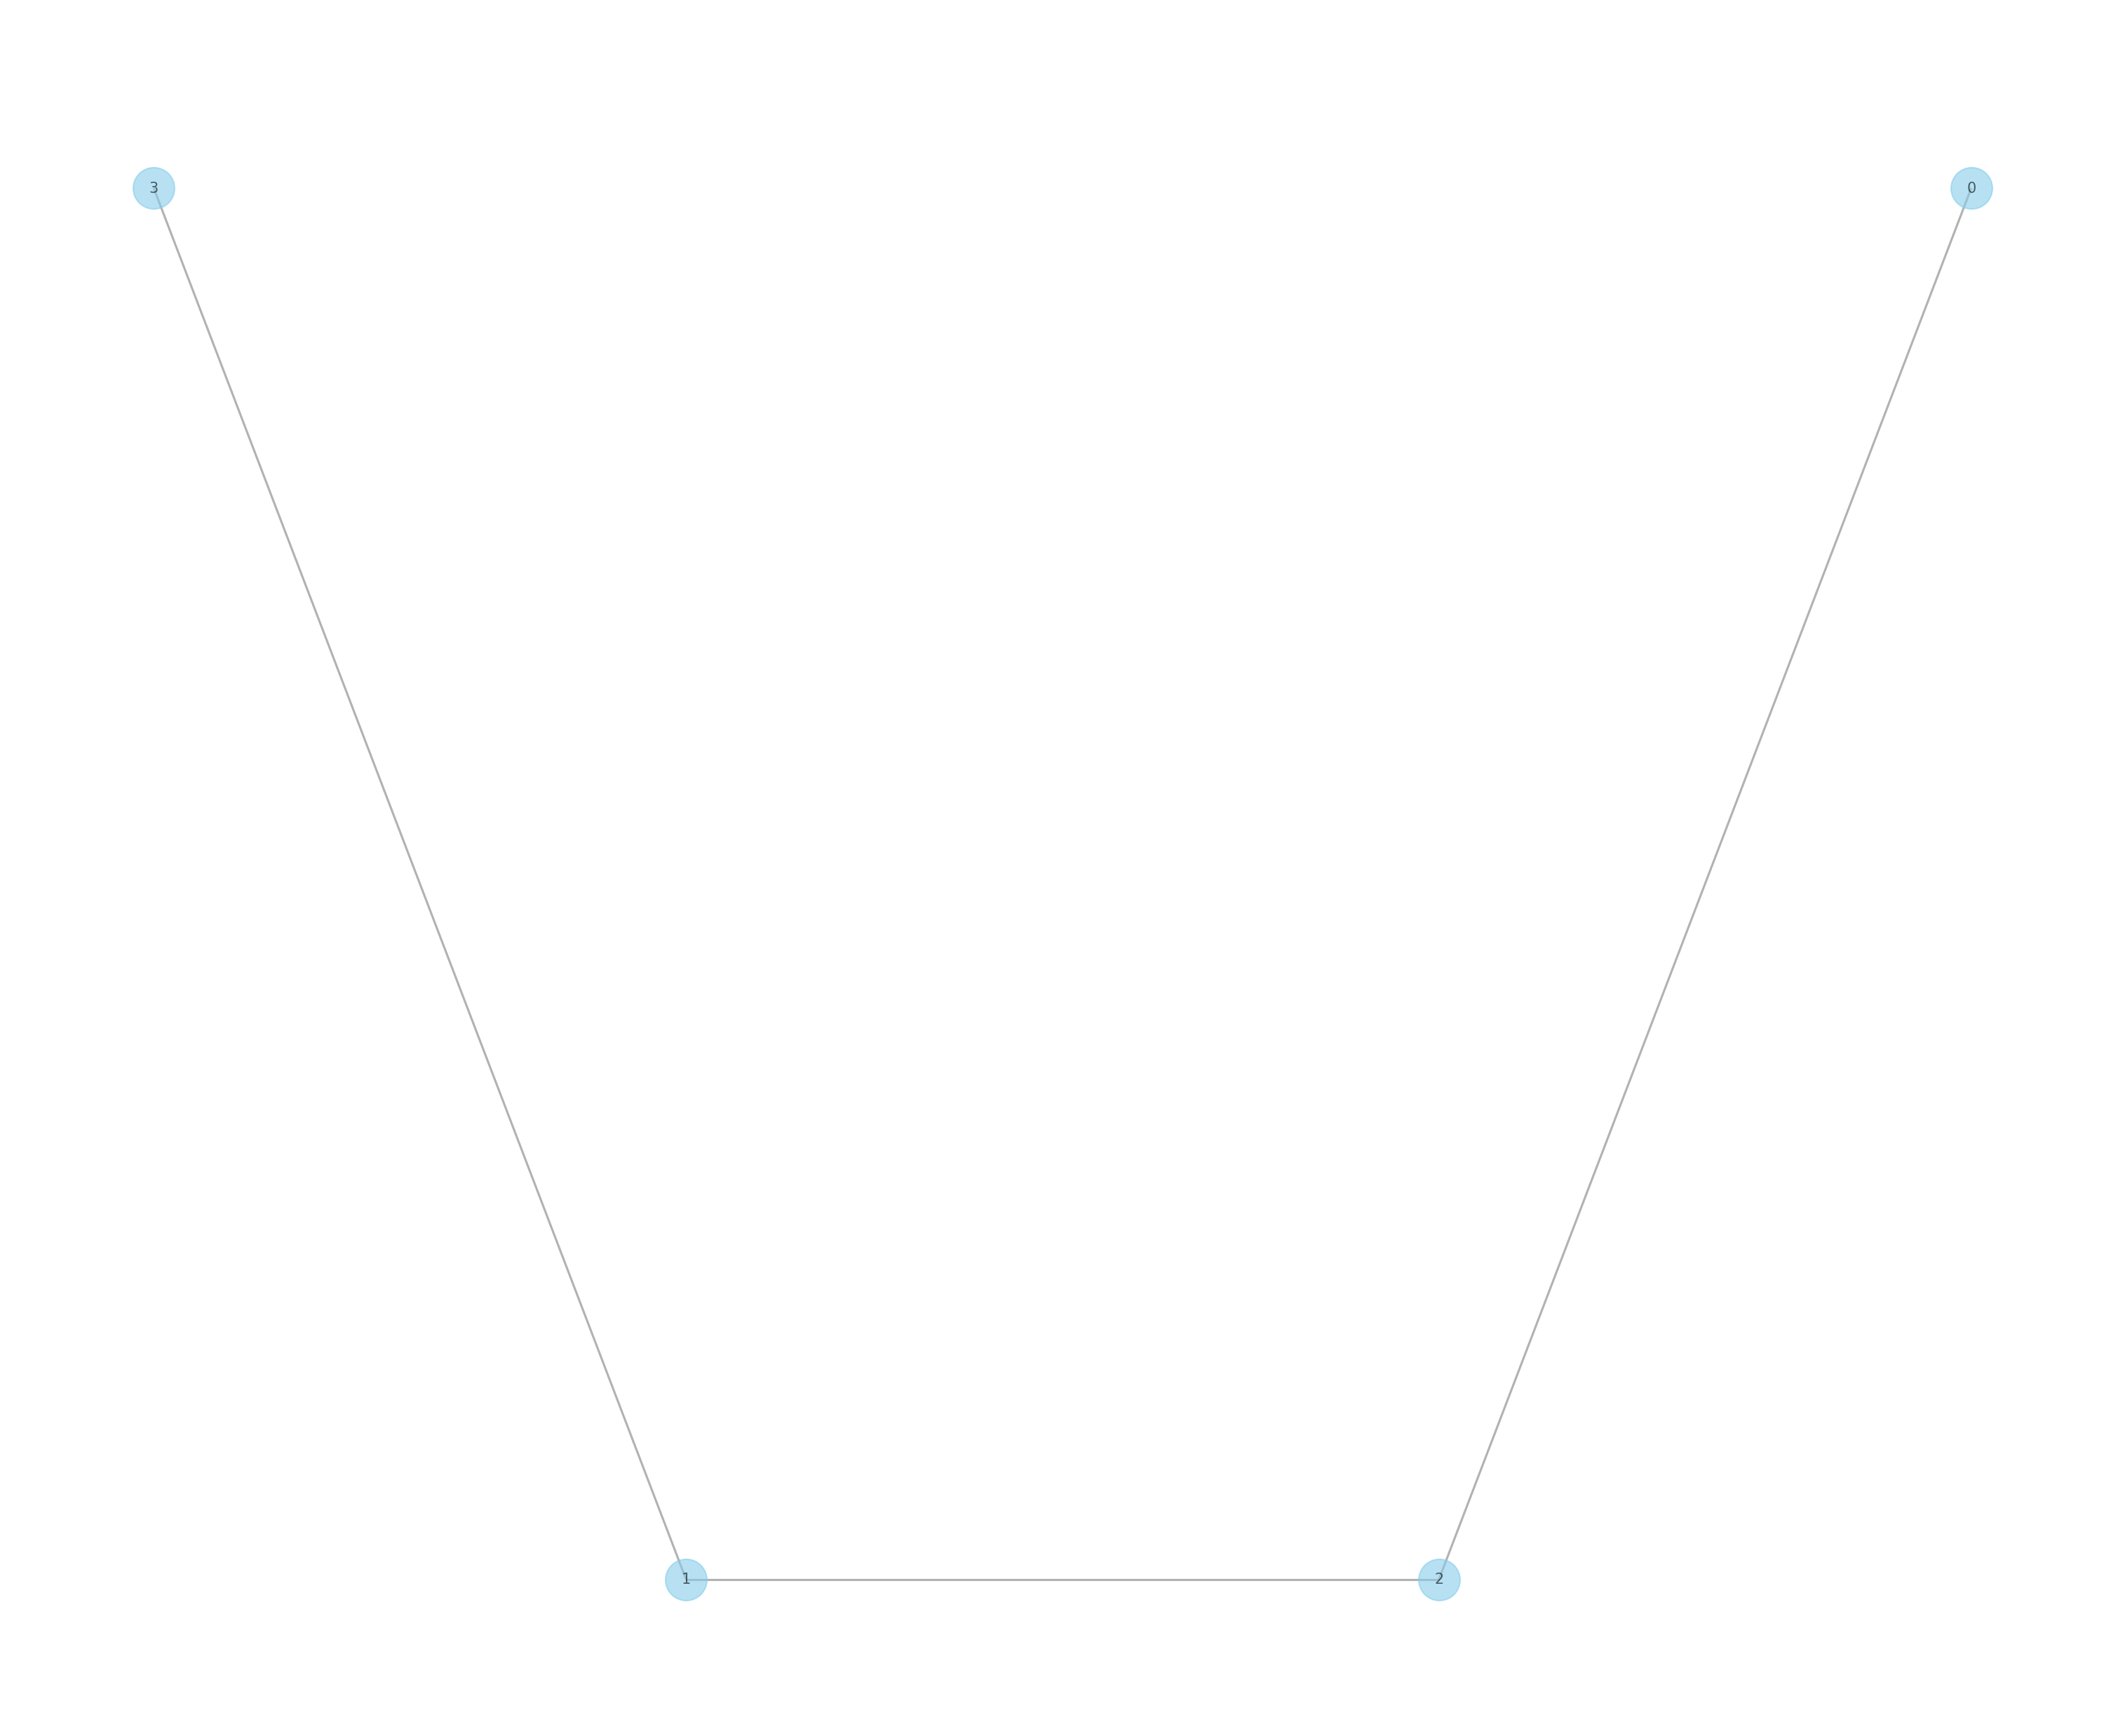

In [37]:
drawSpectralGraph(path, title=" ")



In [36]:
printEigenValues(path)

Eigenvalues:
[0.     0.5858 2.     3.4142]


/var/folders/8r/vkn7nxys7qd013m1phzf6nr80000gn/T/ipykernel_23792/1520346718.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


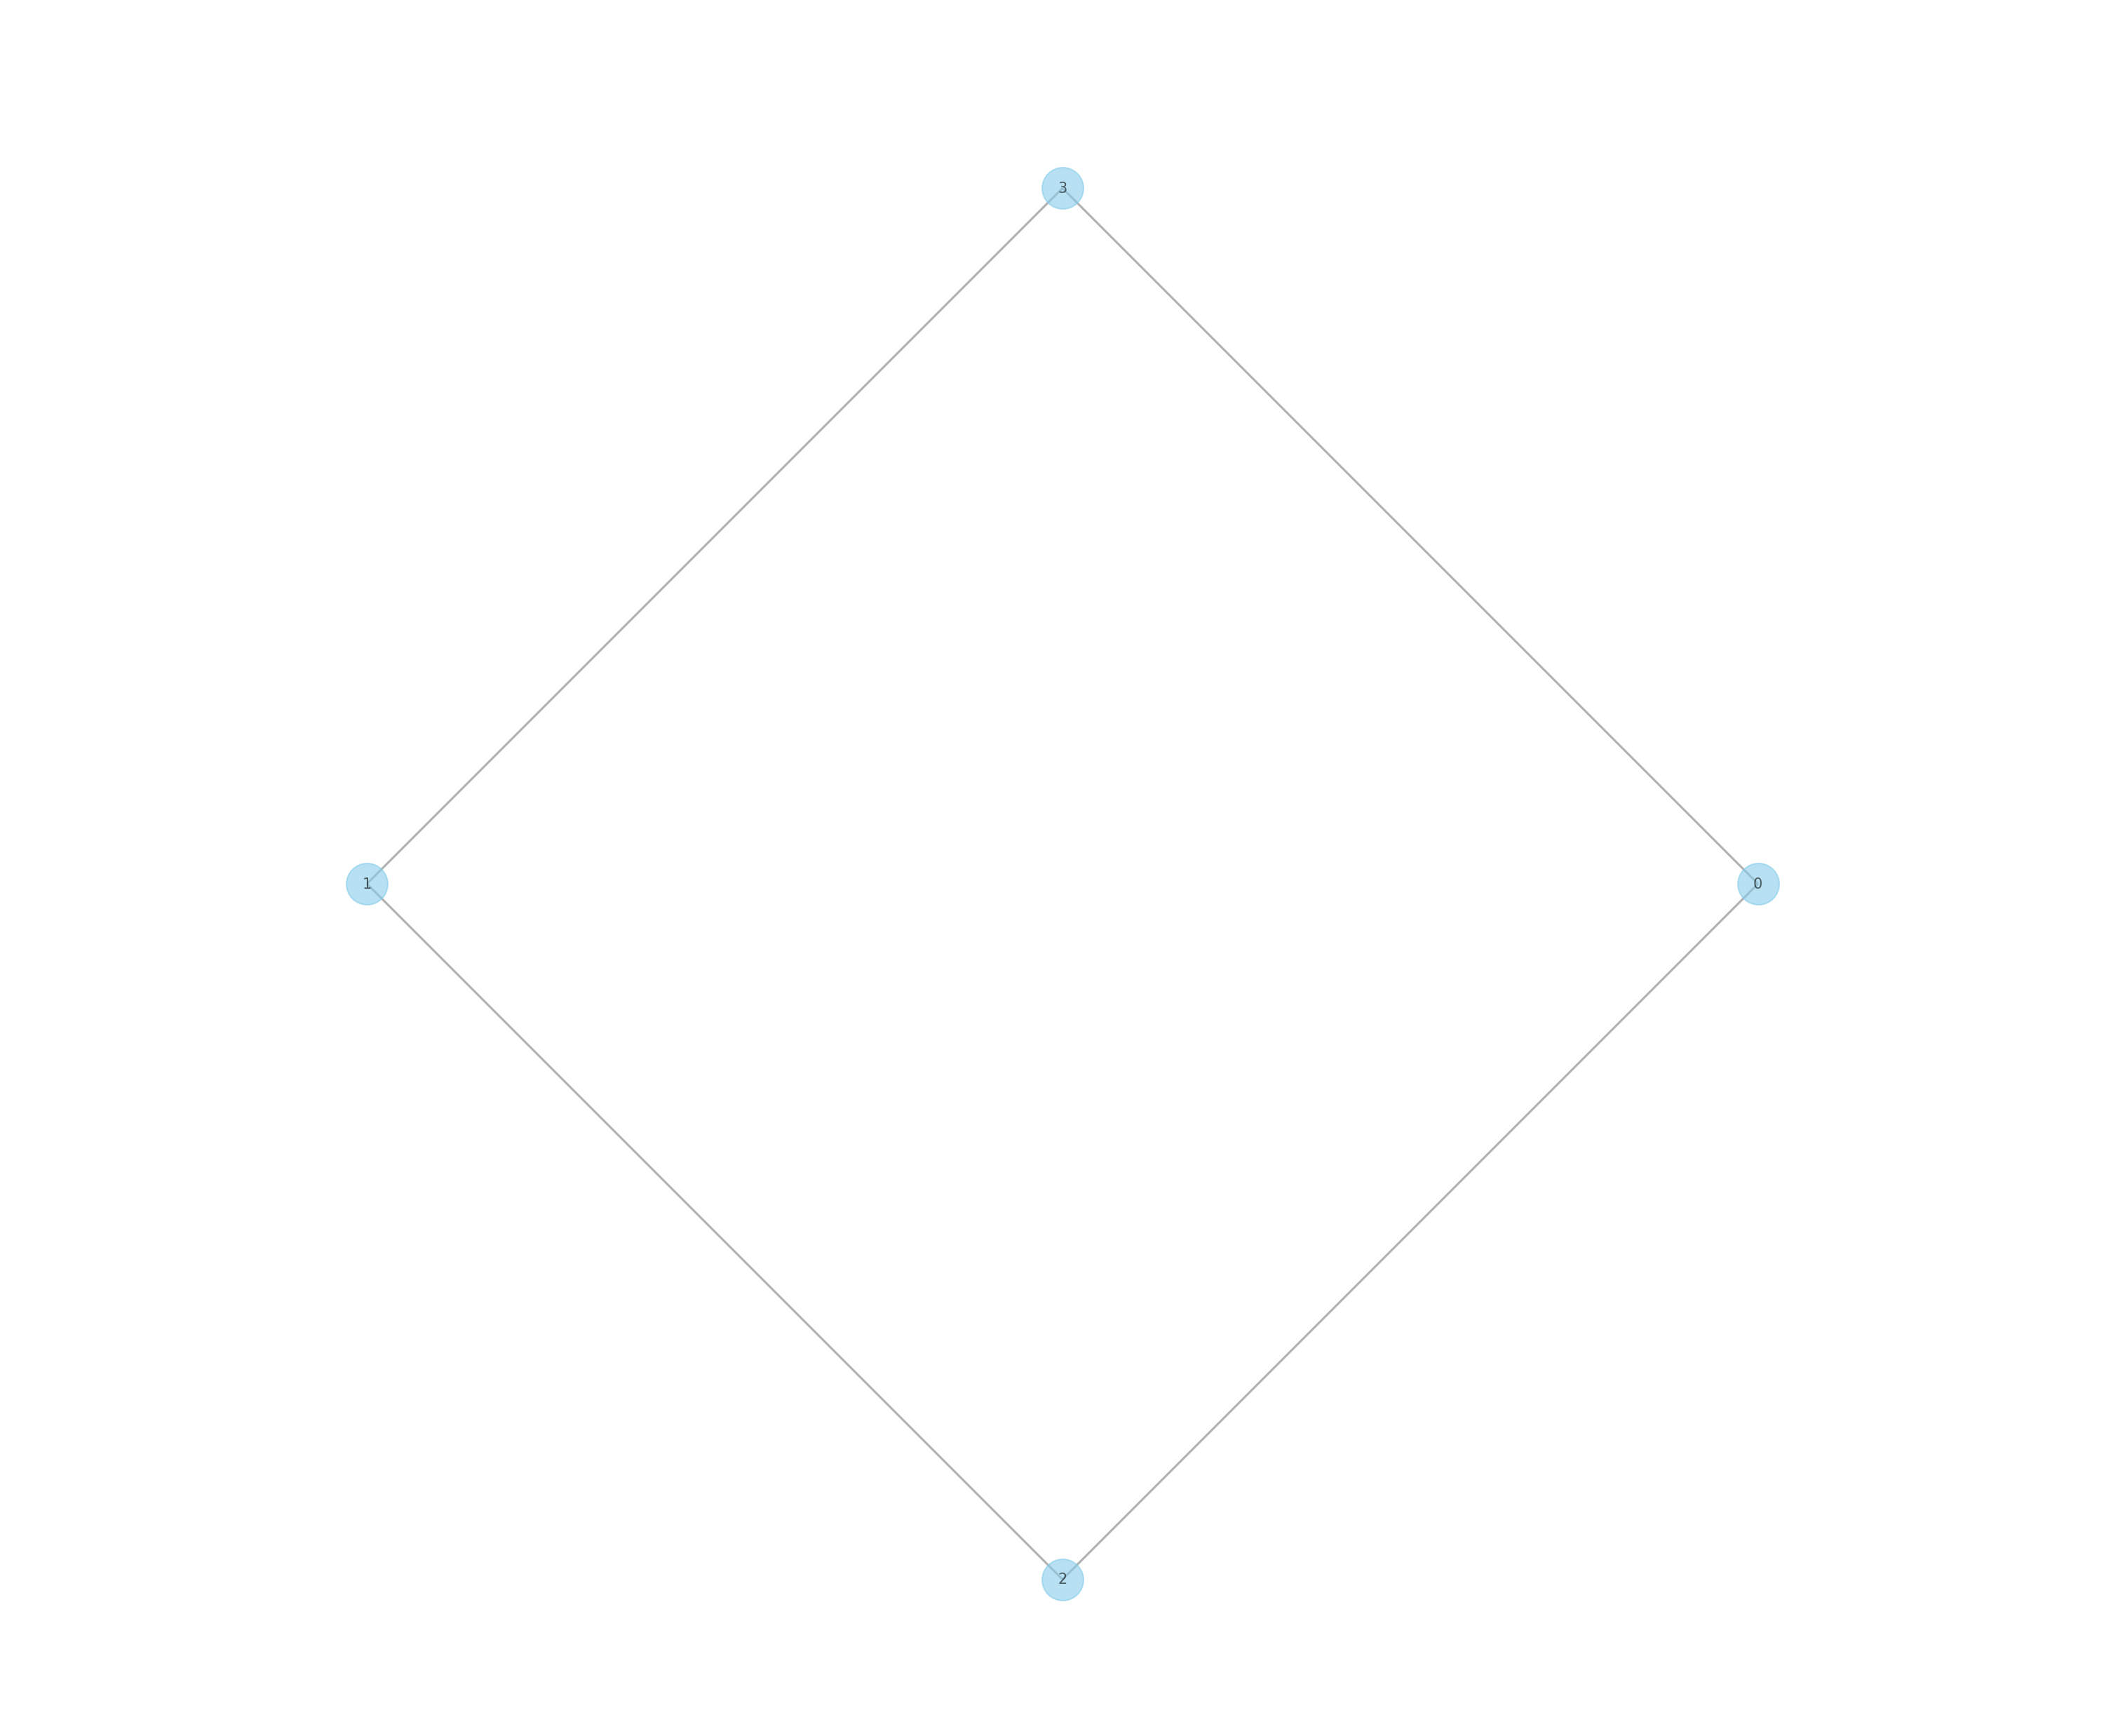

In [24]:
drawSpectralGraph(l4, " ")


In [25]:
printEigenValues(l4)

Eigenvalues:
[0. 2. 2. 4.]


In [42]:
l_paw = np.array([[ 2, -1, -1,  0],
                  [-1,  2, -1,  0],
                  [-1, -1,  3, -1],
                  [ 0,  0, -1,  1]])


/var/folders/8r/vkn7nxys7qd013m1phzf6nr80000gn/T/ipykernel_26941/1520346718.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


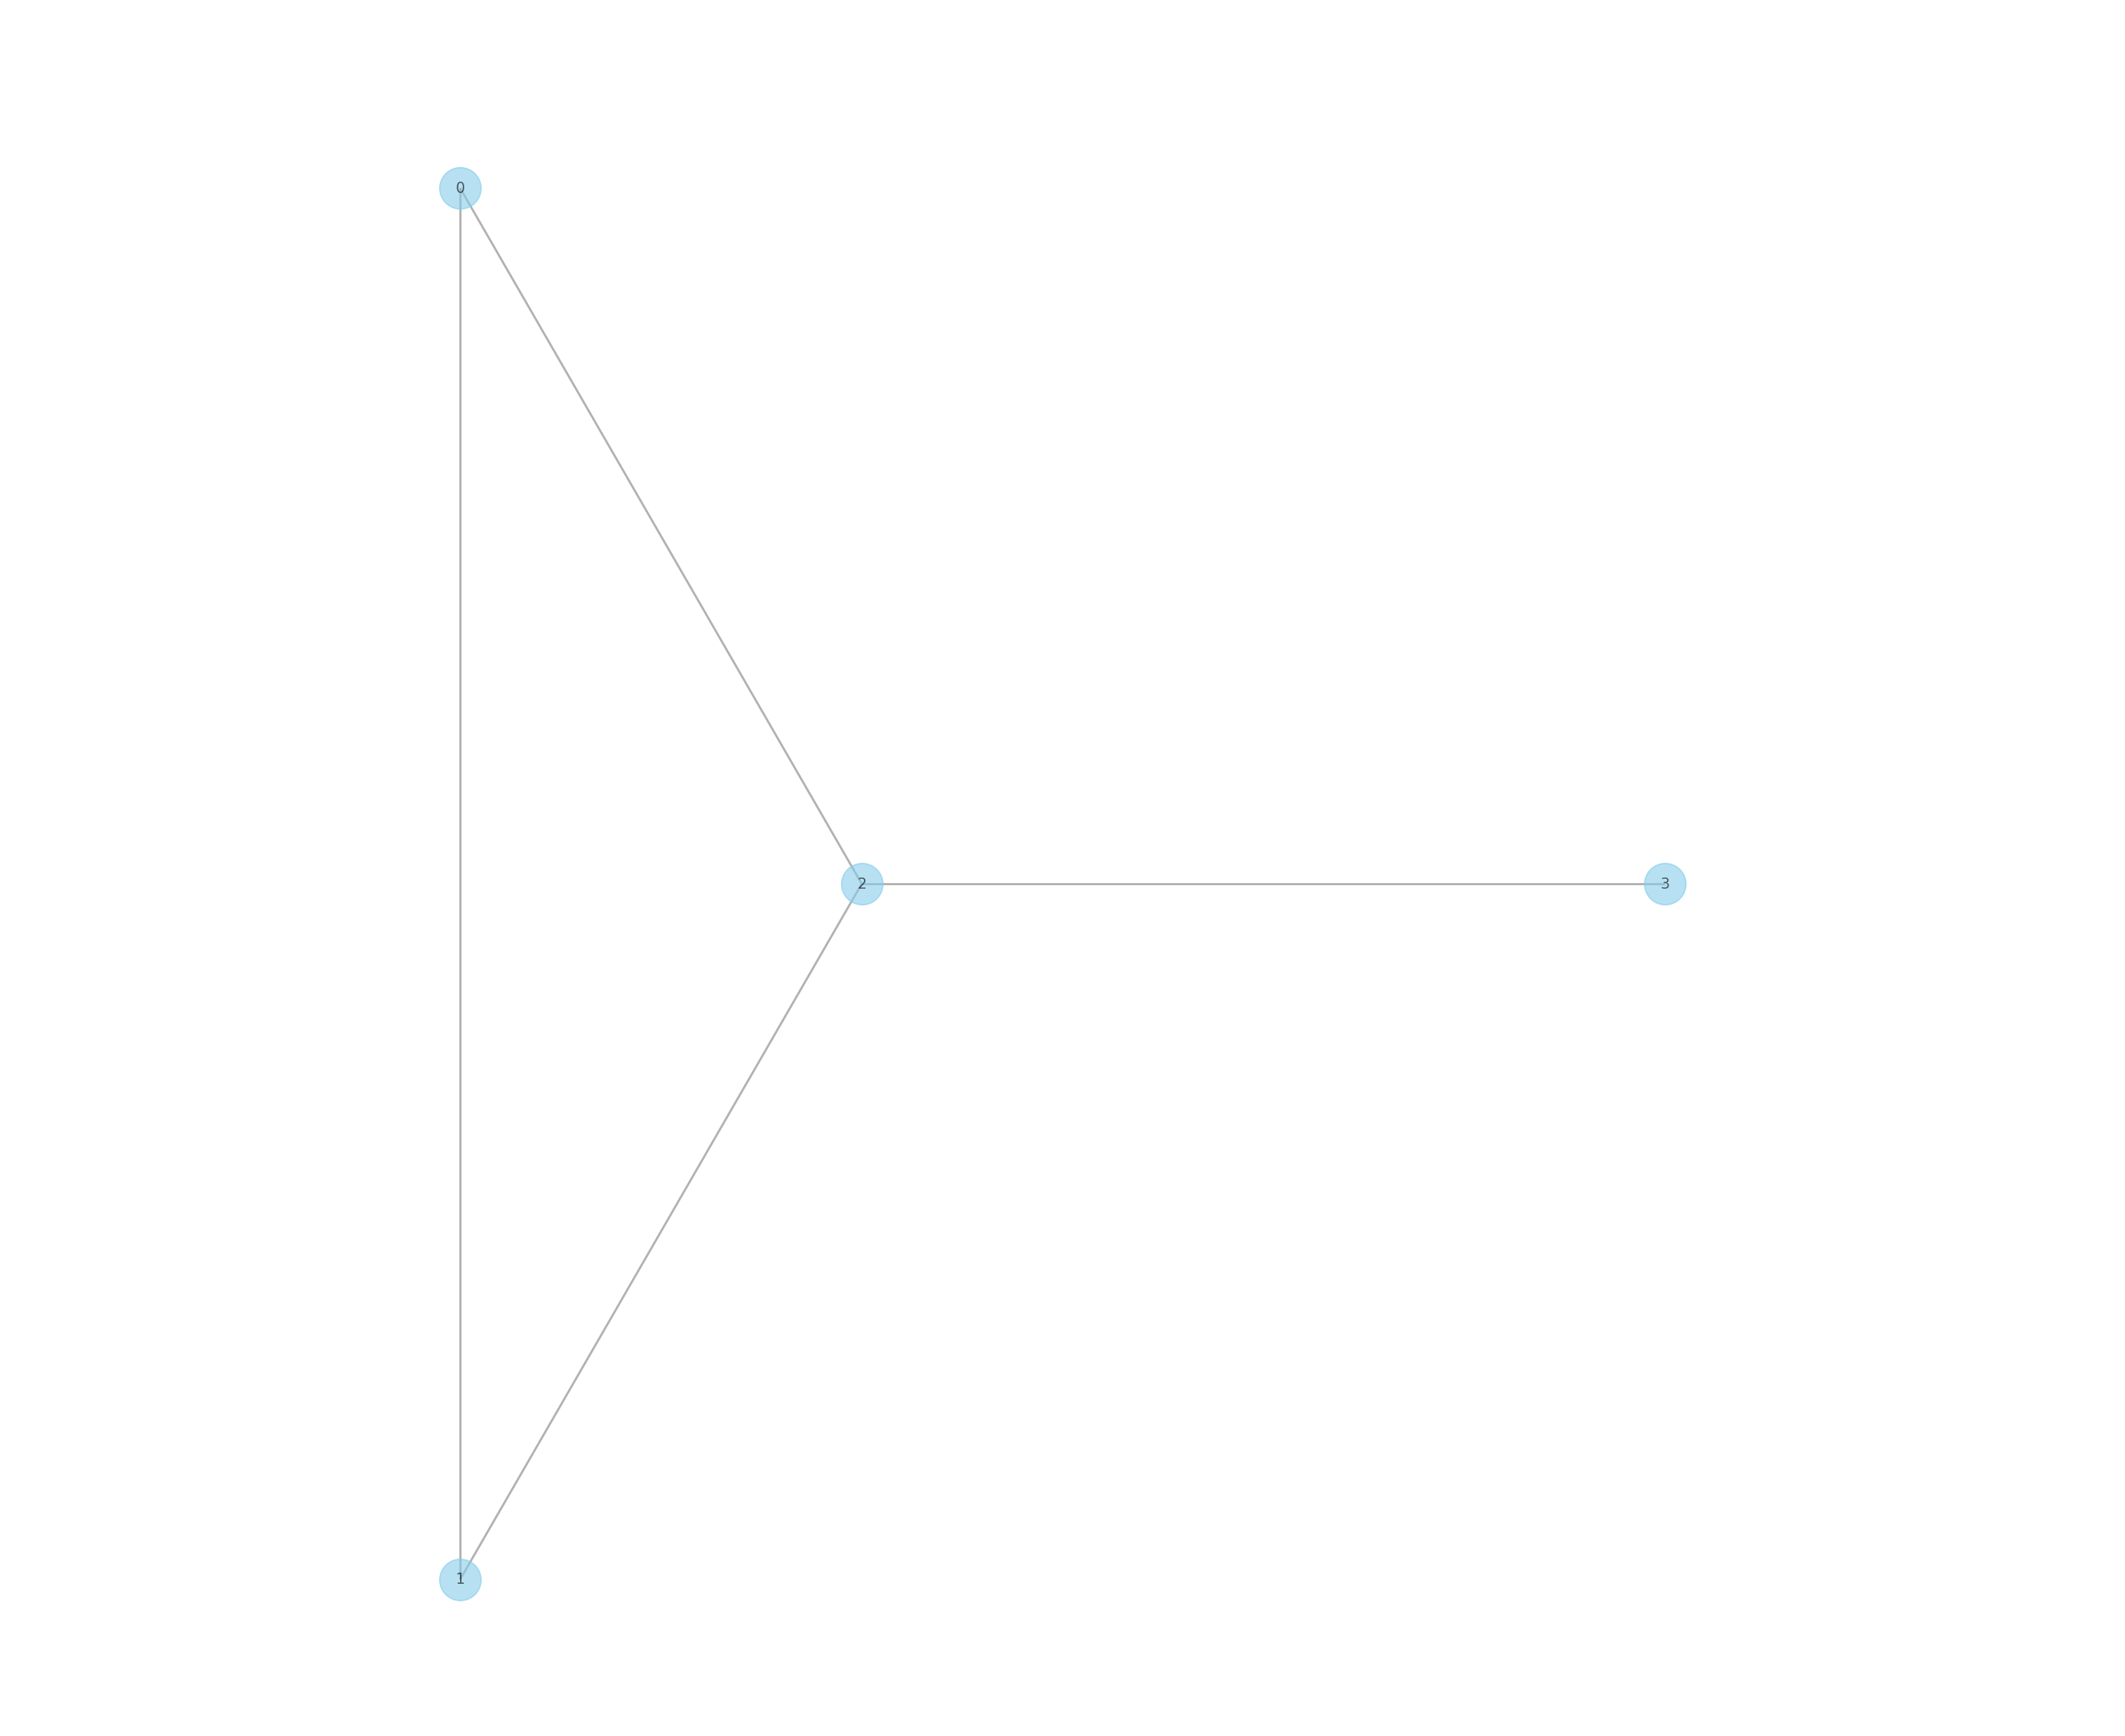

In [43]:
drawSpectralGraph(l_paw, " ")


In [47]:
classical_lambda2_check(l_paw, targetThreshold=0.6, numberOfEdgesToRemove=1)


Verifica classica (lambda_2 dopo rimozione di 1 arco/i, 4 combinazioni):
  indici [0] = (0,1): lambda_2 = 1.0000
  indici [1] = (0,2): lambda_2 = 0.5858  <-- sotto soglia
  indici [2] = (1,2): lambda_2 = 0.5858  <-- sotto soglia
  indici [3] = (2,3): lambda_2 = 0.0000  [disconnette: bin 0, non marcato]
Stampa deglle combinazioni sotto soglia (lambda_2 < 0.6):
  indici [1] = (0,2)
  indici [2] = (1,2)


In [46]:
executeEdgeSearch(l_paw, precision=5, trotterSteps=3,
                  targetThreshold=0.7, numberOfEdgesToRemove=1, shots=1000, showCircuit=True)




Edge search: n_nodes=4, k archi=1, soglia=0.7

Verifica classica (lambda_2 dopo rimozione di 1 arco/i, 4 combinazioni):
  indici [0] = (0,1): lambda_2 = 1.0000
  indici [1] = (0,2): lambda_2 = 0.5858  <-- sotto soglia
  indici [2] = (1,2): lambda_2 = 0.5858  <-- sotto soglia
  indici [3] = (2,3): lambda_2 = 0.0000  [disconnette: bin 0, non marcato]
Stampa deglle combinazioni sotto soglia (lambda_2 < 0.7):
  indici [1] = (0,2)
  indici [2] = (1,2)
Grover edge search: N=16, M=2, iterazioni ottimali k=2 


░ ┌───────┐ ░ ┌──────────┐┌──────────┐ ░       
 q_0: ─────────────░─┤0      ├─░─┤0         ├┤0         ├─░───────
                   ░ │       │ ░ │          ││          │ ░       
 q_1: ─────────────░─┤1      ├─░─┤1         ├┤1         ├─░───────
                   ░ │       │ ░ │          ││          │ ░       
 q_2: ─────────────░─┤2      ├─░─┤2         ├┤2         ├─░───────
                   ░ │       │ ░ │          ││          │ ░       
 q_3: ─────────────░─┤3      ├─░─┤3         ├┤3         ├─░───────
                   ░ │       │ ░ │          ││          │ ░       
 q_4: ─────────────░─┤4      ├─░─┤4         ├┤4         ├─░───────
       ┌───────┐   ░ │       │ ░ │          ││          │ ░       
 q_5: ─┤0      ├───░─┤5      ├─░─┤5         ├┤5         ├─░───────
       │       │   ░ │       │ ░ │          ││          │ ░       
 q_6: ─┤1      ├───░─┤6  QPE ├─░─┤6  G_edge ├┤6  G_edge ├─░───────
       │  U_in │   ░ │       │ ░ │          ││          │ ░       
 q_7: ─┤2      ├───░─┤7      ├─░─┤7         ├┤7         ├─░───────
       │       │   ░ │       │ ░ │          ││          │ ░       
 q_8: ─┤3      ├───░─┤8      ├─░─┤8         ├┤8         ├─░───────
      ┌┴───────┴─┐ ░ │       │ ░ │          ││          │ ░ ┌─┐   
 q_9: ┤0         ├─░─┤9      ├─░─┤9         ├┤9         ├─░─┤M├───
      │          │ ░ │       │ ░ │          ││          │ ░ └╥┘┌─┐
q_10: ┤1         ├─░─┤10     ├─░─┤10        ├┤10        ├─░──╫─┤M├
      │  EdgeSup │ ░ │       │ ░ │          ││          │ ░  ║ └╥┘
q_11: ┤2         ├─░─┤11     ├─░─┤11        ├┤11        ├─░──╫──╫─
      │          │ ░ │       │ ░ │          ││          │ ░  ║  ║ 
q_12: ┤3         ├─░─┤12     ├─░─┤12        ├┤12        ├─░──╫──╫─
      └──────────┘ ░ └───────┘ ░ └──────────┘└──────────┘ ░  ║  ║ 
 c: 2/═══════════════════════════════════════════════════════╩══╩═
                                                             0  1


Tempo di esecuzione: 10.09 s

Campionamenti sul registro degli indici (1000 shots, 1 arco/i):
  indici [2] -> archi (1,2): 498 (49.8%)
  indici [1] -> archi (0,2): 488 (48.8%)
  indici [3] -> archi (2,3): 10 (1.0%)
  indici [0] -> archi (0,1): 4 (0.4%)


In [77]:
executeEdgeSearch(l_paw, precision=5, trotterSteps=3,
                  targetThreshold=0.8, numberOfEdgesToRemove=1, shots=1000, showCircuit=True)

Edge search: n_nodes=4, k archi=1, soglia=0.8

Verifica classica (lambda_2 dopo rimozione di 1 arco/i, 4 combinazioni):
  indici [0] = (0,1): lambda_2 = 1.0000
  indici [1] = (0,2): lambda_2 = 0.5858  <-- sotto soglia
  indici [2] = (1,2): lambda_2 = 0.5858  <-- sotto soglia
  indici [3] = (2,3): lambda_2 = 0.0000  [disconnette: bin 0, non marcato]
Grover edge search: N=16, M=2, iterazioni ottimali k=2 


░ ┌───────┐ ░ ┌──────────┐┌──────────┐ ░       
 q_0: ─────────────░─┤0      ├─░─┤0         ├┤0         ├─░───────
                   ░ │       │ ░ │          ││          │ ░       
 q_1: ─────────────░─┤1      ├─░─┤1         ├┤1         ├─░───────
                   ░ │       │ ░ │          ││          │ ░       
 q_2: ─────────────░─┤2      ├─░─┤2         ├┤2         ├─░───────
                   ░ │       │ ░ │          ││          │ ░       
 q_3: ─────────────░─┤3      ├─░─┤3         ├┤3         ├─░───────
                   ░ │       │ ░ │          ││          │ ░       
 q_4: ─────────────░─┤4      ├─░─┤4         ├┤4         ├─░───────
       ┌───────┐   ░ │       │ ░ │          ││          │ ░       
 q_5: ─┤0      ├───░─┤5      ├─░─┤5         ├┤5         ├─░───────
       │       │   ░ │       │ ░ │          ││          │ ░       
 q_6: ─┤1      ├───░─┤6  QPE ├─░─┤6  G_edge ├┤6  G_edge ├─░───────
       │  U_in │   ░ │       │ ░ │          ││          │ ░       
 q_7: ─┤2      ├───░─┤7      ├─░─┤7         ├┤7         ├─░───────
       │       │   ░ │       │ ░ │          ││          │ ░       
 q_8: ─┤3      ├───░─┤8      ├─░─┤8         ├┤8         ├─░───────
      ┌┴───────┴─┐ ░ │       │ ░ │          ││          │ ░ ┌─┐   
 q_9: ┤0         ├─░─┤9      ├─░─┤9         ├┤9         ├─░─┤M├───
      │          │ ░ │       │ ░ │          ││          │ ░ └╥┘┌─┐
q_10: ┤1         ├─░─┤10     ├─░─┤10        ├┤10        ├─░──╫─┤M├
      │  EdgeSup │ ░ │       │ ░ │          ││          │ ░  ║ └╥┘
q_11: ┤2         ├─░─┤11     ├─░─┤11        ├┤11        ├─░──╫──╫─
      │          │ ░ │       │ ░ │          ││          │ ░  ║  ║ 
q_12: ┤3         ├─░─┤12     ├─░─┤12        ├┤12        ├─░──╫──╫─
      └──────────┘ ░ └───────┘ ░ └──────────┘└──────────┘ ░  ║  ║ 
 c: 2/═══════════════════════════════════════════════════════╩══╩═
                                                             0  1


Tempo di esecuzione: 12.22 s

Campionamenti sul registro degli indici (1000 shots, 1 arco/i):
  indici [1] -> archi (0,2): 508 (50.8%)
  indici [2] -> archi (1,2): 460 (46.0%)
  indici [3] -> archi (2,3): 18 (1.8%)
  indici [0] -> archi (0,1): 14 (1.4%)


La verifica classica e' parametrica sul numero di archi: con `numberOfEdgesToRemove=2` elenca tutte le coppie senza ripetizione, con 3 le triple, ecc. il circuito campiona *tuple ordinate* (duplicati e indici non validi inclusi); la stampa dei risultati le aggrega in insiemi e segnala i casi anomali.

In [78]:
classical_lambda2_check(l_paw, targetThreshold=0.7, numberOfEdgesToRemove=2)


Verifica classica (lambda_2 dopo rimozione di 2 arco/i, 6 combinazioni):
  indici [0, 1] = (0,1), (0,2): lambda_2 = 0.0000  [disconnette: bin 0, non marcato]
  indici [0, 2] = (0,1), (1,2): lambda_2 = 0.0000  [disconnette: bin 0, non marcato]
  indici [0, 3] = (0,1), (2,3): lambda_2 = 0.0000  [disconnette: bin 0, non marcato]
  indici [1, 2] = (0,2), (1,2): lambda_2 = 0.0000  [disconnette: bin 0, non marcato]
  indici [1, 3] = (0,2), (2,3): lambda_2 = 0.0000  [disconnette: bin 0, non marcato]
  indici [2, 3] = (1,2), (2,3): lambda_2 = 0.0000  [disconnette: bin 0, non marcato]


### Grafo 4 nodi completamente connesso

In [56]:
lfc = generateSparseGraphWithNNodes(4)

lfc = addEdge(lfc, 0, 1)
lfc = addEdge(lfc, 3, 2)



Grafo generato: N=4, Grado Max=2 (Limite=2), Connesso=True


/var/folders/8r/vkn7nxys7qd013m1phzf6nr80000gn/T/ipykernel_26941/1520346718.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


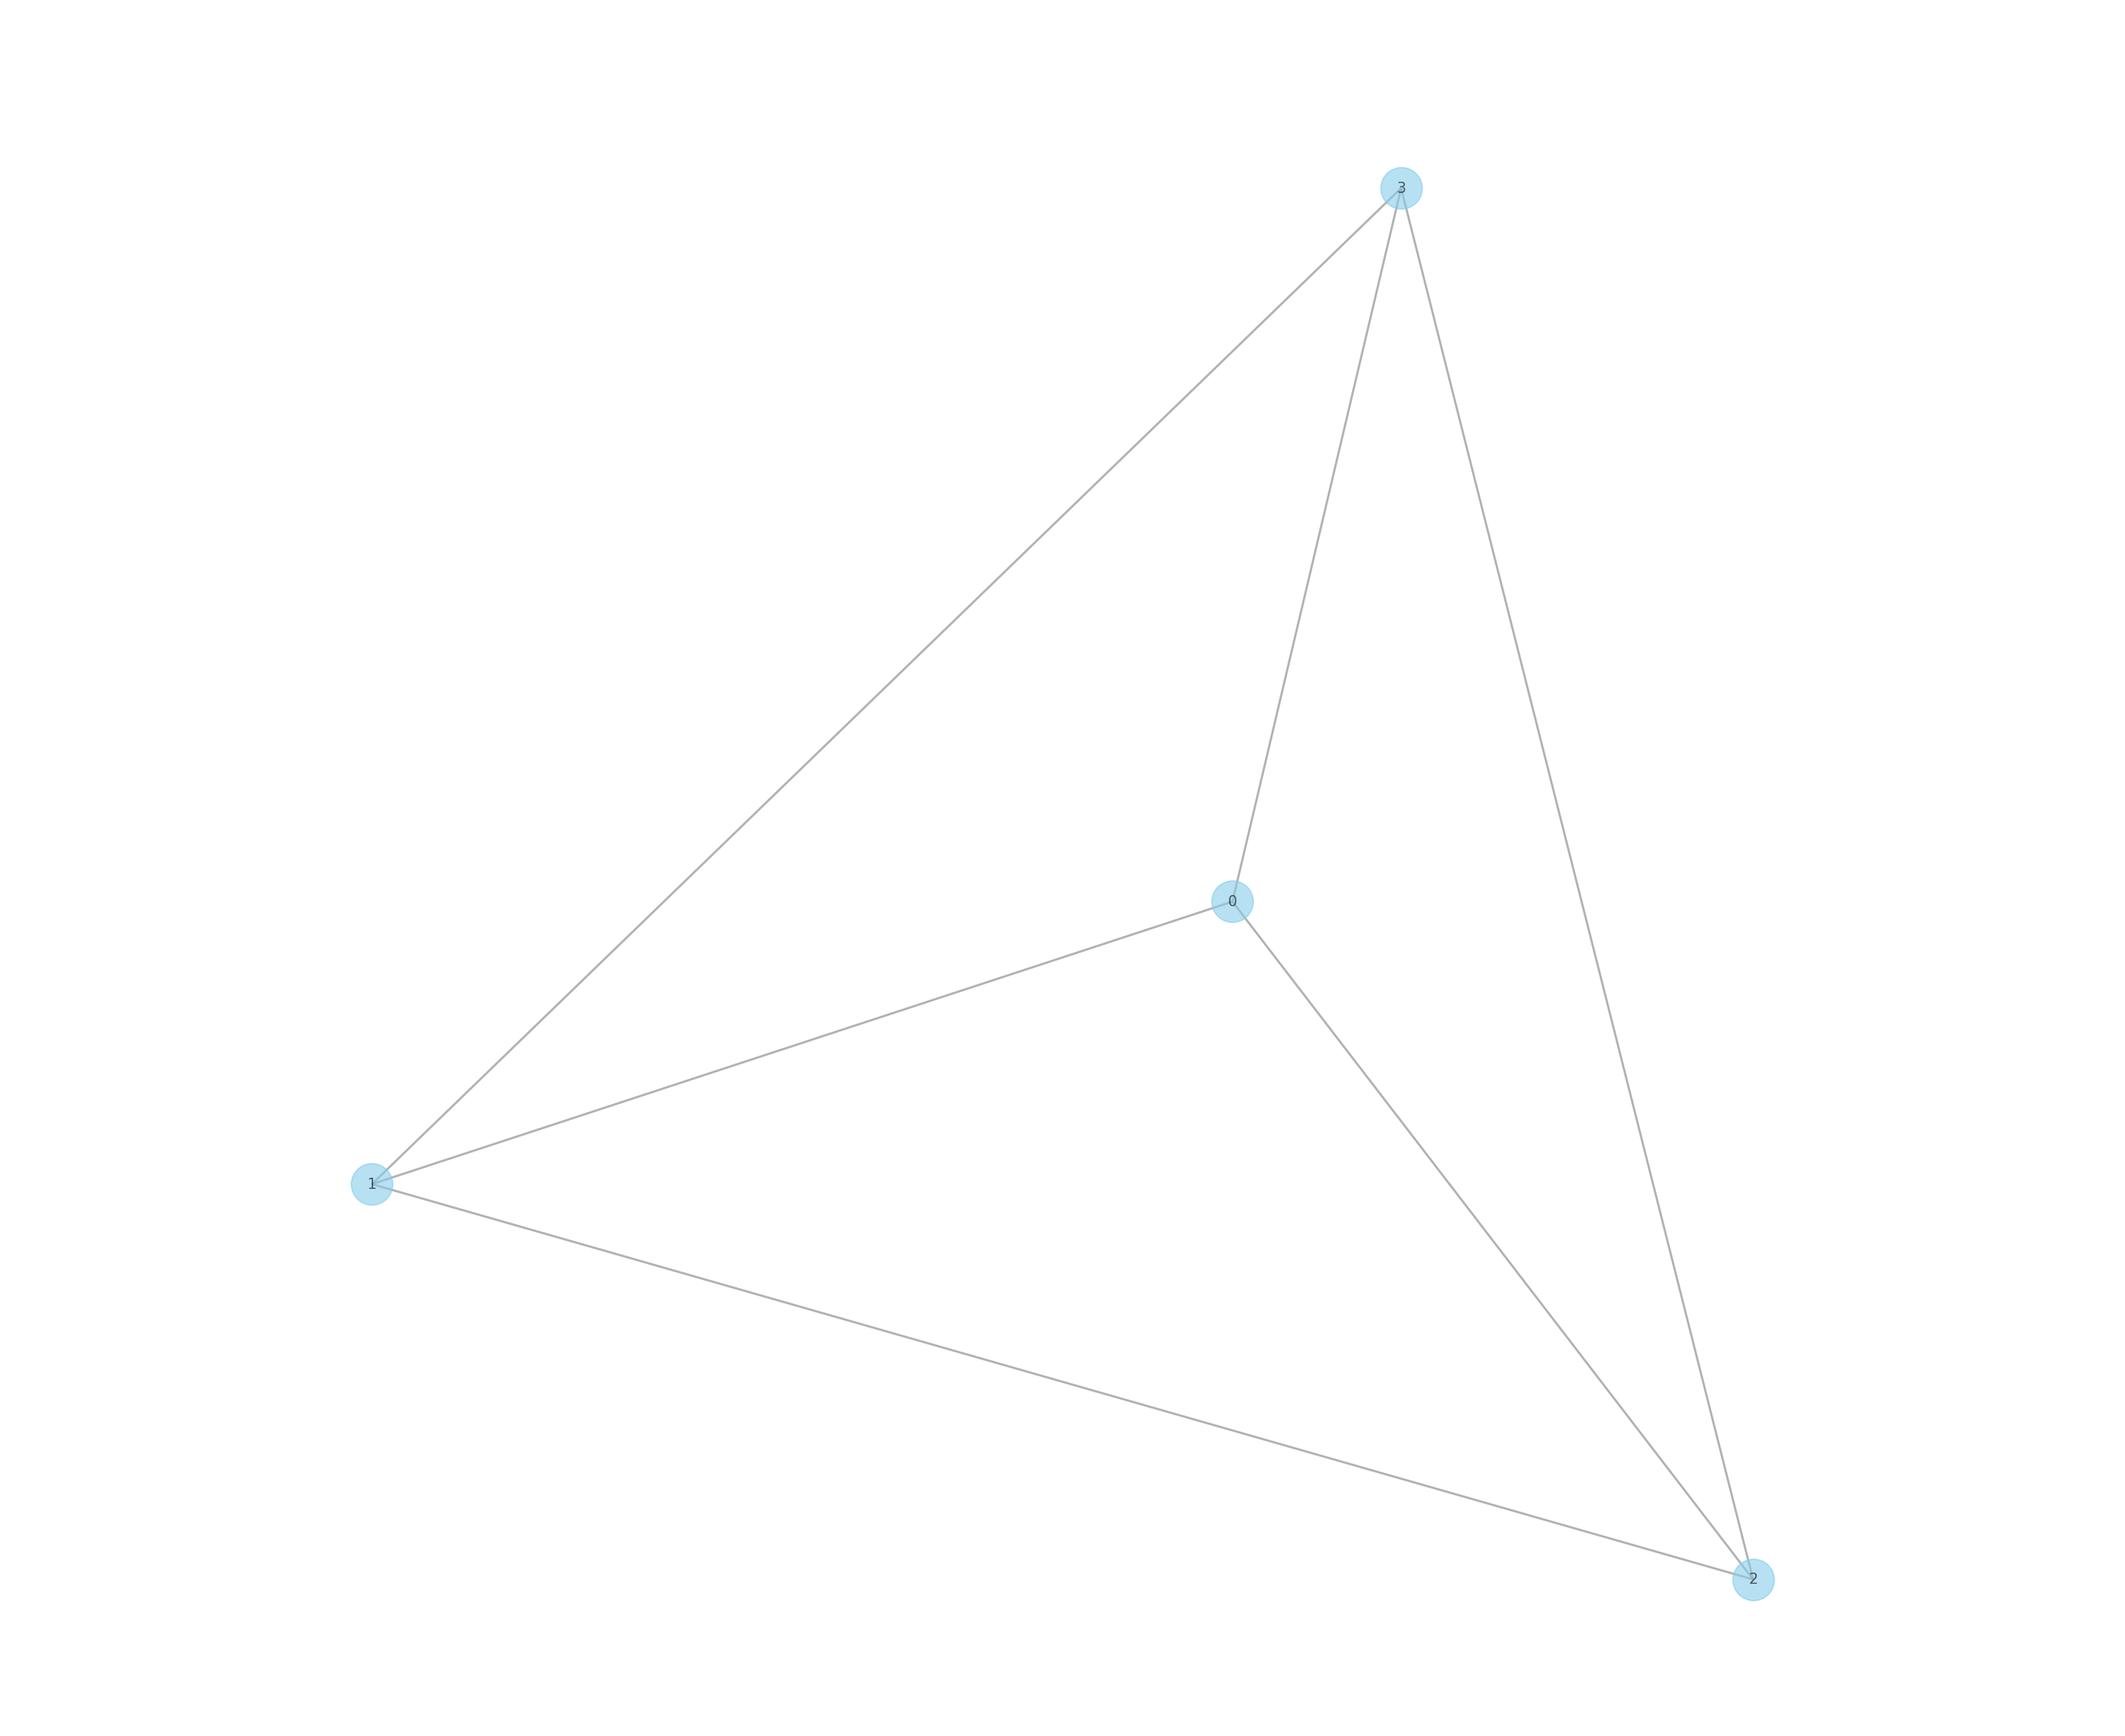

In [58]:
drawSpectralGraph(lfc, ' ')

In [145]:
classical_lambda2_check(lfc, targetThreshold=0.586, numberOfEdgesToRemove=3)


Verifica classica (lambda_2 dopo rimozione di 3 arco/i, 20 combinazioni):
  indici [0, 1, 2] = (0,1), (0,2), (0,3): lambda_2 = 0.0000  [disconnette: bin 0, non marcato]
  indici [0, 1, 3] = (0,1), (0,2), (1,2): lambda_2 = 1.0000
  indici [0, 1, 4] = (0,1), (0,2), (1,3): lambda_2 = 0.5858  <-- sotto soglia
  indici [0, 1, 5] = (0,1), (0,2), (2,3): lambda_2 = 0.5858  <-- sotto soglia
  indici [0, 2, 3] = (0,1), (0,3), (1,2): lambda_2 = 0.5858  <-- sotto soglia
  indici [0, 2, 4] = (0,1), (0,3), (1,3): lambda_2 = 1.0000
  indici [0, 2, 5] = (0,1), (0,3), (2,3): lambda_2 = 0.5858  <-- sotto soglia
  indici [0, 3, 4] = (0,1), (1,2), (1,3): lambda_2 = 0.0000  [disconnette: bin 0, non marcato]
  indici [0, 3, 5] = (0,1), (1,2), (2,3): lambda_2 = 0.5858  <-- sotto soglia
  indici [0, 4, 5] = (0,1), (1,3), (2,3): lambda_2 = 0.5858  <-- sotto soglia
  indici [1, 2, 3] = (0,2), (0,3), (1,2): lambda_2 = 0.5858  <-- sotto soglia
  indici [1, 2, 4] = (0,2), (0,3), (1,3): lambda_2 = 0.5858  <-- sott

In [148]:
executeEdgeSearch(lfc, precision=5, trotterSteps=3,
                  targetThreshold=0.8, numberOfEdgesToRemove=3, shots=1000, showCircuit=False)

Edge search: n_nodes=4, k archi=3, soglia=0.8

Verifica classica (lambda_2 dopo rimozione di 3 arco/i, 20 combinazioni):
  indici [0, 1, 2] = (0,1), (0,2), (0,3): lambda_2 = 0.0000  [disconnette: bin 0, non marcato]
  indici [0, 1, 3] = (0,1), (0,2), (1,2): lambda_2 = 1.0000
  indici [0, 1, 4] = (0,1), (0,2), (1,3): lambda_2 = 0.5858  <-- sotto soglia
  indici [0, 1, 5] = (0,1), (0,2), (2,3): lambda_2 = 0.5858  <-- sotto soglia
  indici [0, 2, 3] = (0,1), (0,3), (1,2): lambda_2 = 0.5858  <-- sotto soglia
  indici [0, 2, 4] = (0,1), (0,3), (1,3): lambda_2 = 1.0000
  indici [0, 2, 5] = (0,1), (0,3), (2,3): lambda_2 = 0.5858  <-- sotto soglia
  indici [0, 3, 4] = (0,1), (1,2), (1,3): lambda_2 = 0.0000  [disconnette: bin 0, non marcato]
  indici [0, 3, 5] = (0,1), (1,2), (2,3): lambda_2 = 0.5858  <-- sotto soglia
  indici [0, 4, 5] = (0,1), (1,3), (2,3): lambda_2 = 0.5858  <-- sotto soglia
  indici [1, 2, 3] = (0,2), (0,3), (1,2): lambda_2 = 0.5858  <-- sotto soglia
  indici [1, 2, 4] = (0

## Test 8 nodi 

In [48]:
l8 = generateSparseGraphWithNNodes(8)

l8 = addEdge(l8, 4,6)

l8 = addEdge(l8, 0,7)








Grafo generato: N=8, Grado Max=3 (Limite=3), Connesso=True


/var/folders/8r/vkn7nxys7qd013m1phzf6nr80000gn/T/ipykernel_26941/1520346718.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


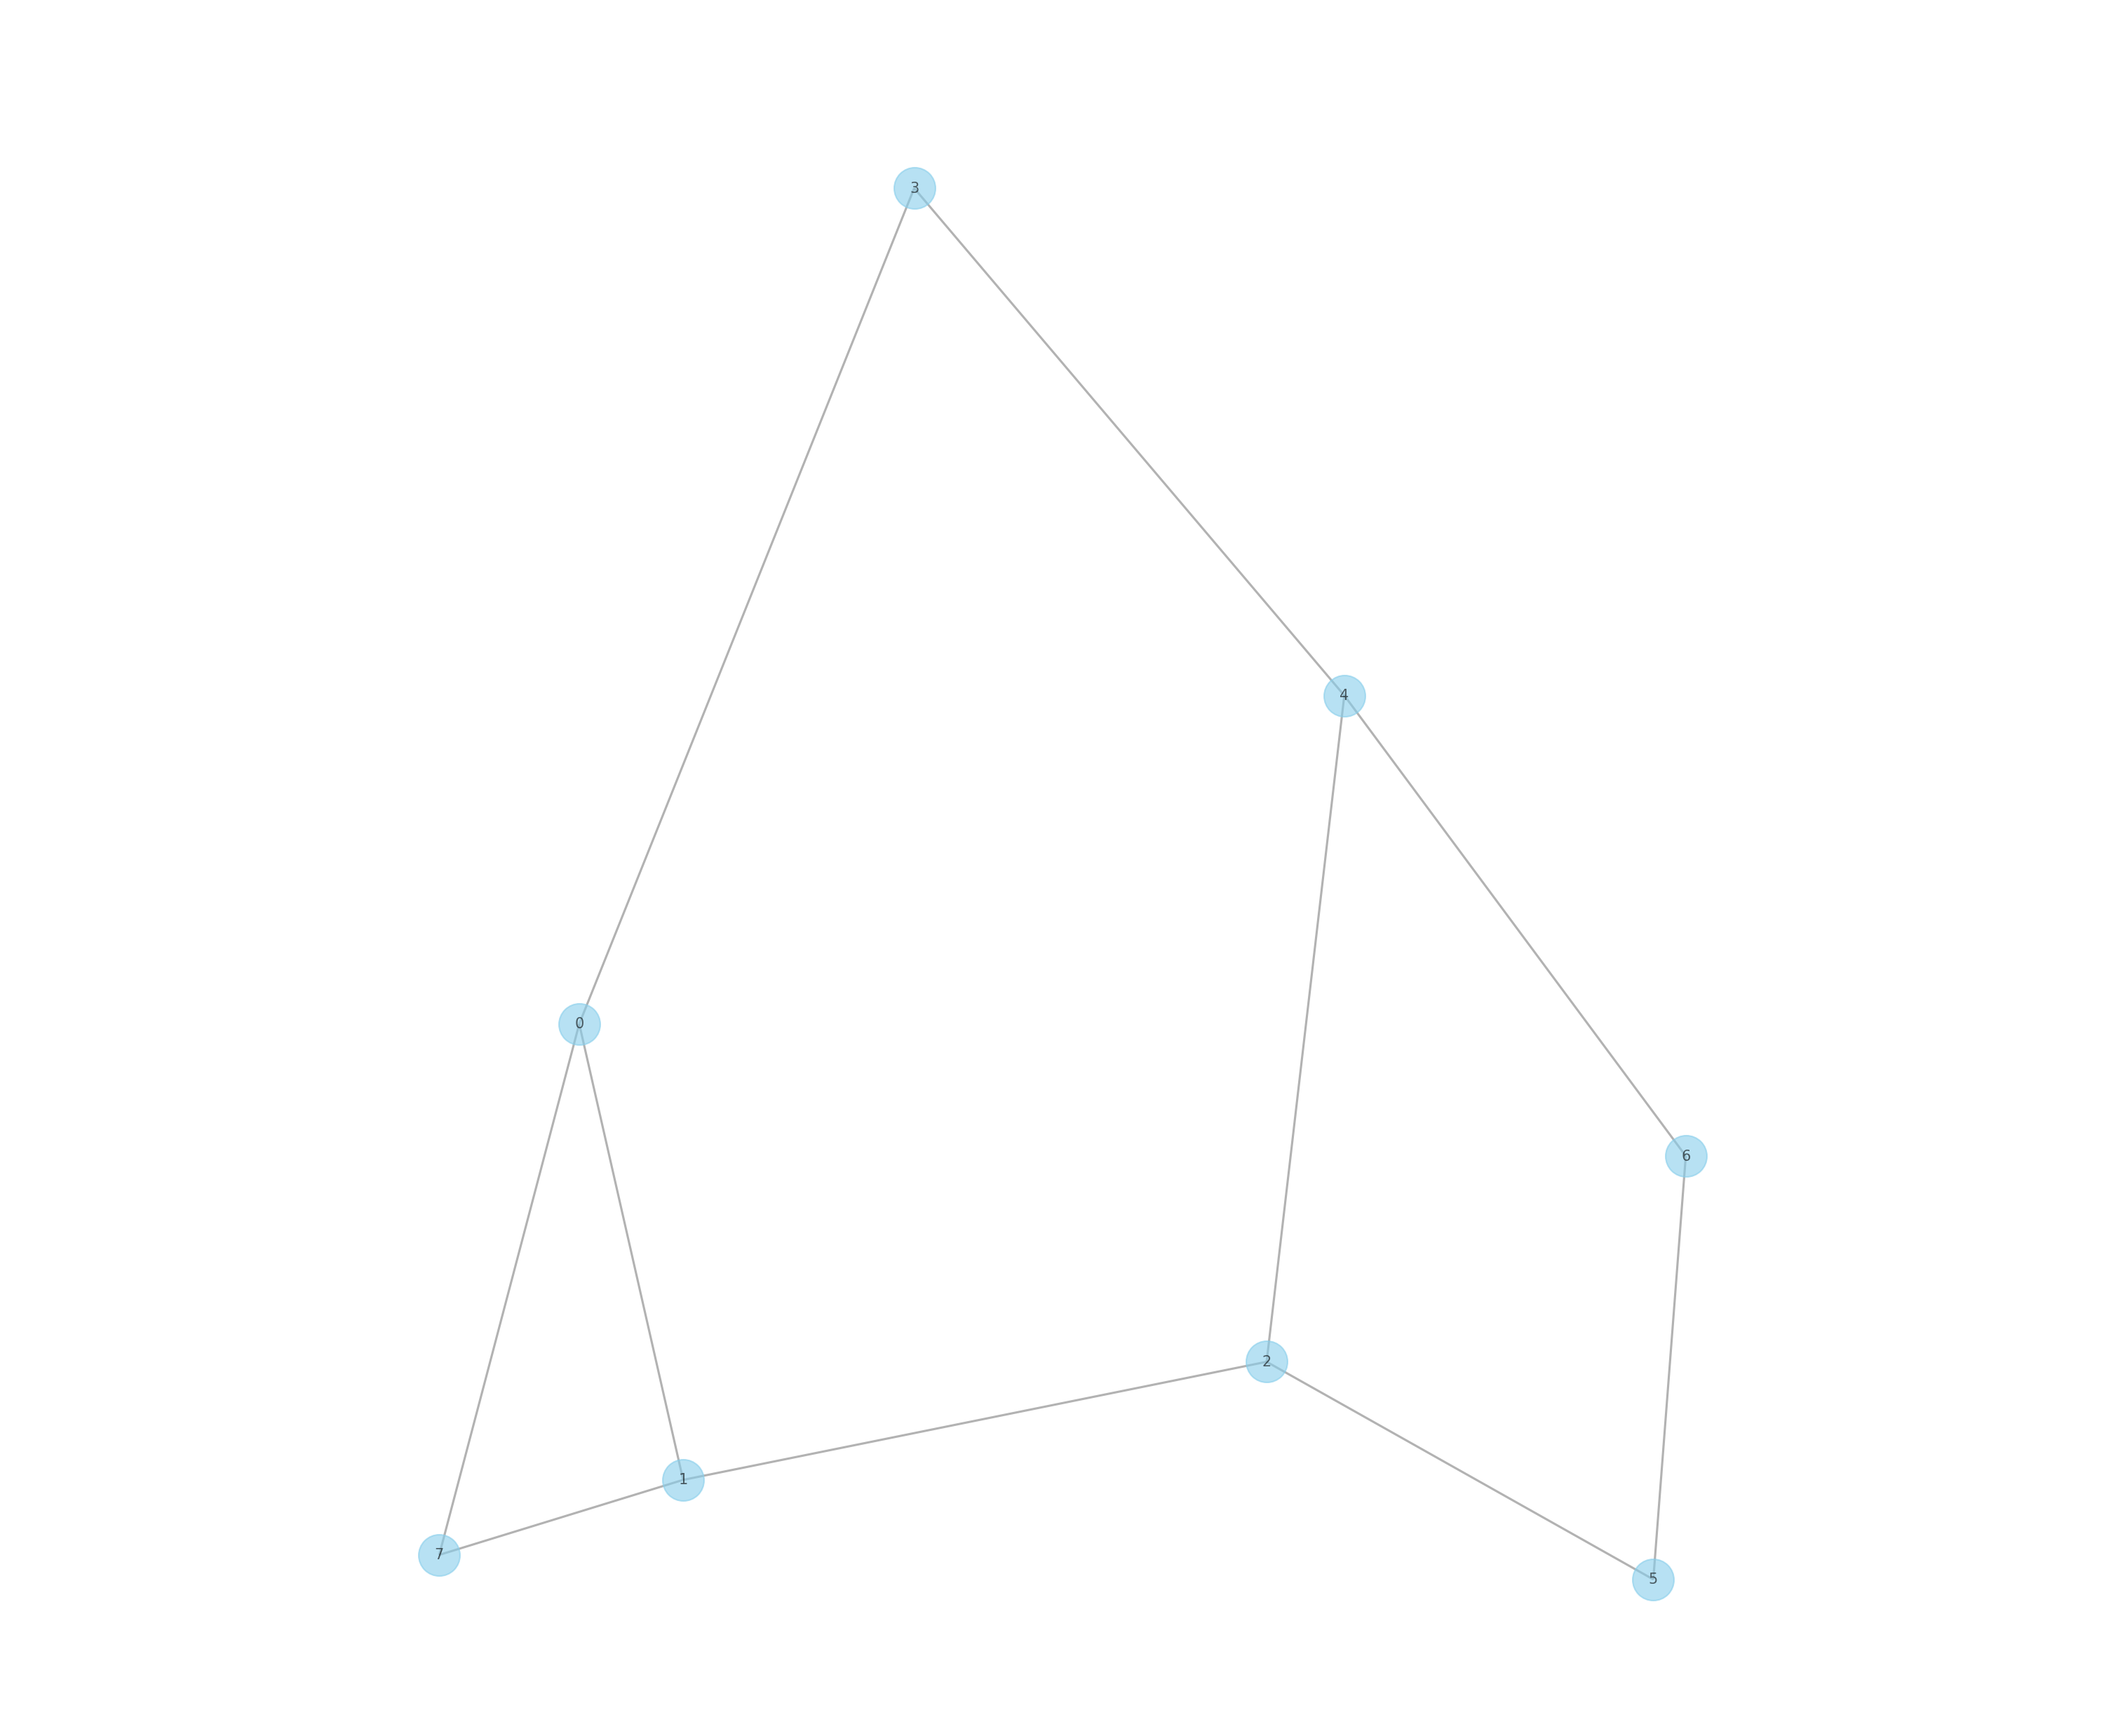

Eigenvalues:
[0.     0.608  1.4261 2.3148 2.7285 3.501  4.4339 4.9877]


In [49]:
drawSpectralGraph(l8, " ")
printEigenValues(l8)

In [52]:
classical_lambda2_check(l8, targetThreshold=0.25, numberOfEdgesToRemove=1)


Verifica classica (lambda_2 dopo rimozione di 1 arco/i, 10 combinazioni):
  indici [0] = (0,1): lambda_2 = 0.5858
  indici [1] = (0,3): lambda_2 = 0.3074
  indici [2] = (0,7): lambda_2 = 0.5509
  indici [3] = (1,2): lambda_2 = 0.2243  <-- sotto soglia
  indici [4] = (1,7): lambda_2 = 0.4915
  indici [5] = (2,4): lambda_2 = 0.5858
  indici [6] = (2,5): lambda_2 = 0.3376
  indici [7] = (3,4): lambda_2 = 0.2786
  indici [8] = (4,6): lambda_2 = 0.3555
  indici [9] = (5,6): lambda_2 = 0.5858
Stampa deglle combinazioni sotto soglia (lambda_2 < 0.25):
  indici [3] = (1,2)


In [53]:
executeEdgeSearch(l8, precision=6, trotterSteps=5,
                  targetThreshold=0.25, numberOfEdgesToRemove=1, shots=1000)

Edge search: n_nodes=8, k archi=1, soglia=0.25

Verifica classica (lambda_2 dopo rimozione di 1 arco/i, 10 combinazioni):
  indici [0] = (0,1): lambda_2 = 0.5858
  indici [1] = (0,3): lambda_2 = 0.3074
  indici [2] = (0,7): lambda_2 = 0.5509
  indici [3] = (1,2): lambda_2 = 0.2243  <-- sotto soglia
  indici [4] = (1,7): lambda_2 = 0.4915
  indici [5] = (2,4): lambda_2 = 0.5858
  indici [6] = (2,5): lambda_2 = 0.3376
  indici [7] = (3,4): lambda_2 = 0.2786
  indici [8] = (4,6): lambda_2 = 0.3555
  indici [9] = (5,6): lambda_2 = 0.5858
Stampa deglle combinazioni sotto soglia (lambda_2 < 0.25):
  indici [3] = (1,2)
Grover edge search: N=128, M=1, iterazioni ottimali k=8 

Tempo di esecuzione: 762.45 s

Campionamenti sul registro degli indici (1000 shots, 1 arco/i):
  indici [3] -> archi (1,2): 693 (69.3%)
  indici [1] -> archi (0,3): 66 (6.6%)
  indici [6] -> archi (2,5): 65 (6.5%)
  indici [0] -> archi (0,1): 20 (2.0%)
  indici [14] -> archi idx14?: 19 (1.9%)  [indice non valido]
  indic

In [54]:
executeEdgeSearch(l8, precision=6, trotterSteps=5,
                  targetThreshold=0.40, numberOfEdgesToRemove=1, shots=1000)

Edge search: n_nodes=8, k archi=1, soglia=0.4

Verifica classica (lambda_2 dopo rimozione di 1 arco/i, 10 combinazioni):
  indici [0] = (0,1): lambda_2 = 0.5858
  indici [1] = (0,3): lambda_2 = 0.3074  <-- sotto soglia
  indici [2] = (0,7): lambda_2 = 0.5509
  indici [3] = (1,2): lambda_2 = 0.2243  <-- sotto soglia
  indici [4] = (1,7): lambda_2 = 0.4915
  indici [5] = (2,4): lambda_2 = 0.5858
  indici [6] = (2,5): lambda_2 = 0.3376  <-- sotto soglia
  indici [7] = (3,4): lambda_2 = 0.2786  <-- sotto soglia
  indici [8] = (4,6): lambda_2 = 0.3555  <-- sotto soglia
  indici [9] = (5,6): lambda_2 = 0.5858
Stampa deglle combinazioni sotto soglia (lambda_2 < 0.4):
  indici [1] = (0,3)
  indici [3] = (1,2)
  indici [6] = (2,5)
  indici [7] = (3,4)
  indici [8] = (4,6)
Grover edge search: N=128, M=5, iterazioni ottimali k=3 

Tempo di esecuzione: 324.97 s

Campionamenti sul registro degli indici (1000 shots, 1 arco/i):
  indici [8] -> archi (4,6): 198 (19.8%)
  indici [3] -> archi (1,2): 187

In [58]:
executeEdgeSearch(l8, precision=6, trotterSteps=5,
                  targetThreshold=0.34, numberOfEdgesToRemove=1, shots=1000, showCircuit=True)

Edge search: n_nodes=8, k archi=1, soglia=0.34

Verifica classica (lambda_2 dopo rimozione di 1 arco/i, 10 combinazioni):
  indici [0] = (0,1): lambda_2 = 0.5858
  indici [1] = (0,3): lambda_2 = 0.3074  <-- sotto soglia
  indici [2] = (0,7): lambda_2 = 0.5509
  indici [3] = (1,2): lambda_2 = 0.2243  <-- sotto soglia
  indici [4] = (1,7): lambda_2 = 0.4915
  indici [5] = (2,4): lambda_2 = 0.5858
  indici [6] = (2,5): lambda_2 = 0.3376  <-- sotto soglia
  indici [7] = (3,4): lambda_2 = 0.2786  <-- sotto soglia
  indici [8] = (4,6): lambda_2 = 0.3555
  indici [9] = (5,6): lambda_2 = 0.5858
Grover edge search: N=128, M=4, iterazioni ottimali k=4, P(successo) teorica = 0.999


░ ┌───────┐ ░ ┌──────────┐┌──────────┐┌──────────┐┌──────────┐ ░             
 q_0: ─────────────░─┤0      ├─░─┤0         ├┤0         ├┤0         ├┤0         ├─░─────────────
                   ░ │       │ ░ │          ││          ││          ││          │ ░             
 q_1: ─────────────░─┤1      ├─░─┤1         ├┤1         ├┤1         ├┤1         ├─░─────────────
                   ░ │       │ ░ │          ││          ││          ││          │ ░             
 q_2: ─────────────░─┤2      ├─░─┤2         ├┤2         ├┤2         ├┤2         ├─░─────────────
                   ░ │       │ ░ │          ││          ││          ││          │ ░             
 q_3: ─────────────░─┤3      ├─░─┤3         ├┤3         ├┤3         ├┤3         ├─░─────────────
                   ░ │       │ ░ │          ││          ││          ││          │ ░             
 q_4: ─────────────░─┤4      ├─░─┤4         ├┤4         ├┤4         ├┤4         ├─░─────────────
                   ░ │       │ ░ │          ││          ││          ││          │ ░             
 q_5: ─────────────░─┤5      ├─░─┤5         ├┤5         ├┤5         ├┤5         ├─░─────────────
       ┌───────┐   ░ │       │ ░ │          ││          ││          ││          │ ░             
 q_6: ─┤0      ├───░─┤6      ├─░─┤6         ├┤6         ├┤6         ├┤6         ├─░─────────────
       │       │   ░ │       │ ░ │          ││          ││          ││          │ ░             
 q_7: ─┤1      ├───░─┤7      ├─░─┤7         ├┤7         ├┤7         ├┤7         ├─░─────────────
       │       │   ░ │       │ ░ │          ││          ││          ││          │ ░             
 q_8: ─┤2      ├───░─┤8      ├─░─┤8         ├┤8         ├┤8         ├┤8         ├─░─────────────
       │  U_in │   ░ │   QPE │ ░ │   G_edge ││   G_edge ││   G_edge ││   G_edge │ ░             
 q_9: ─┤3      ├───░─┤9      ├─░─┤9         ├┤9         ├┤9         ├┤9         ├─░─────────────
       │       │   ░ │       │ ░ │          ││          ││          ││          │ ░             
q_10: ─┤4      ├───░─┤10     ├─░─┤10        ├┤10        ├┤10        ├┤10        ├─░─────────────
       │       │   ░ │       │ ░ │          ││          ││          ││          │ ░             
q_11: ─┤5      ├───░─┤11     ├─░─┤11        ├┤11        ├┤11        ├┤11        ├─░─────────────
      ┌┴───────┴─┐ ░ │       │ ░ │          ││          ││          ││          │ ░ ┌─┐         
q_12: ┤0         ├─░─┤12     ├─░─┤12        ├┤12        ├┤12        ├┤12        ├─░─┤M├─────────
      │          │ ░ │       │ ░ │          ││          ││          ││          │ ░ └╥┘┌─┐      
q_13: ┤1         ├─░─┤13     ├─░─┤13        ├┤13        ├┤13        ├┤13        ├─░──╫─┤M├──────
      │          │ ░ │       │ ░ │          ││          ││          ││          │ ░  ║ └╥┘┌─┐   
q_14: ┤2         ├─░─┤14     ├─░─┤14        ├┤14        ├┤14        ├┤14        ├─░──╫──╫─┤M├───
      │  EdgeSup │ ░ │       │ ░ │          ││          ││          ││          │ ░  ║  ║ └╥┘┌─┐
q_15: ┤3         ├─░─┤15     ├─░─┤15        ├┤15        ├┤15        ├┤15        ├─░──╫──╫──╫─┤M├
      │          │ ░ │       │ ░ │          ││          ││          ││          │ ░  ║  ║  ║ └╥┘
q_16: ┤4         ├─░─┤16     ├─░─┤16        ├┤16        ├┤16        ├┤16        ├─░──╫──╫──╫──╫─
      │          │ ░ │       │ ░ │          ││          ││          ││          │ ░  ║  ║  ║  ║ 
q_17: ┤5         ├─░─┤17     ├─░─┤17        ├┤17        ├┤17        ├┤17        ├─░──╫──╫──╫──╫─
      └──────────┘ ░ └───────┘ ░ └──────────┘└──────────┘└──────────┘└──────────┘ ░  ║  ║  ║  ║ 
 c: 4/═══════════════════════════════════════════════════════════════════════════════╩══╩══╩══╩═
                                                                                     0  1  2  3


Tempo di esecuzione: 411.11 s

Campionamenti sul registro degli indici (1000 shots, 1 arco/i):
  indici [7] -> archi (3,4): 331 (33.1%)
  indici [3] -> archi (1,2): 281 (28.1%)
  indici [1] -> archi (0,3): 227 (22.7%)
  indici [6] -> archi (2,5): 68 (6.8%)
  indici [8] -> archi (4,6): 24 (2.4%)
  indici [12] -> archi idx12?: 10 (1.0%)  [indice non valido]
  indici [4] -> archi (1,7): 10 (1.0%)
  indici [0] -> archi (0,1): 9 (0.9%)
  indici [14] -> archi idx14?: 7 (0.7%)  [indice non valido]
  indici [9] -> archi (5,6): 7 (0.7%)
  indici [13] -> archi idx13?: 7 (0.7%)  [indice non valido]
  indici [10] -> archi idx10?: 5 (0.5%)  [indice non valido]
  indici [11] -> archi idx11?: 5 (0.5%)  [indice non valido]
  indici [2] -> archi (0,7): 4 (0.4%)
  indici [15] -> archi idx15?: 3 (0.3%)  [indice non valido]
  indici [5] -> archi (2,4): 2 (0.2%)


{(10,): 5,
 (15,): 3,
 (11,): 5,
 (14,): 7,
 (5,): 2,
 (9,): 7,
 (8,): 24,
 (12,): 10,
 (13,): 7,
 (1,): 227,
 (7,): 331,
 (2,): 4,
 (3,): 281,
 (4,): 10,
 (0,): 9,
 (6,): 68}

Grafo generato: N=8, Grado Max=3 (Limite=3), Connesso=True


/var/folders/8r/vkn7nxys7qd013m1phzf6nr80000gn/T/ipykernel_23792/1520346718.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


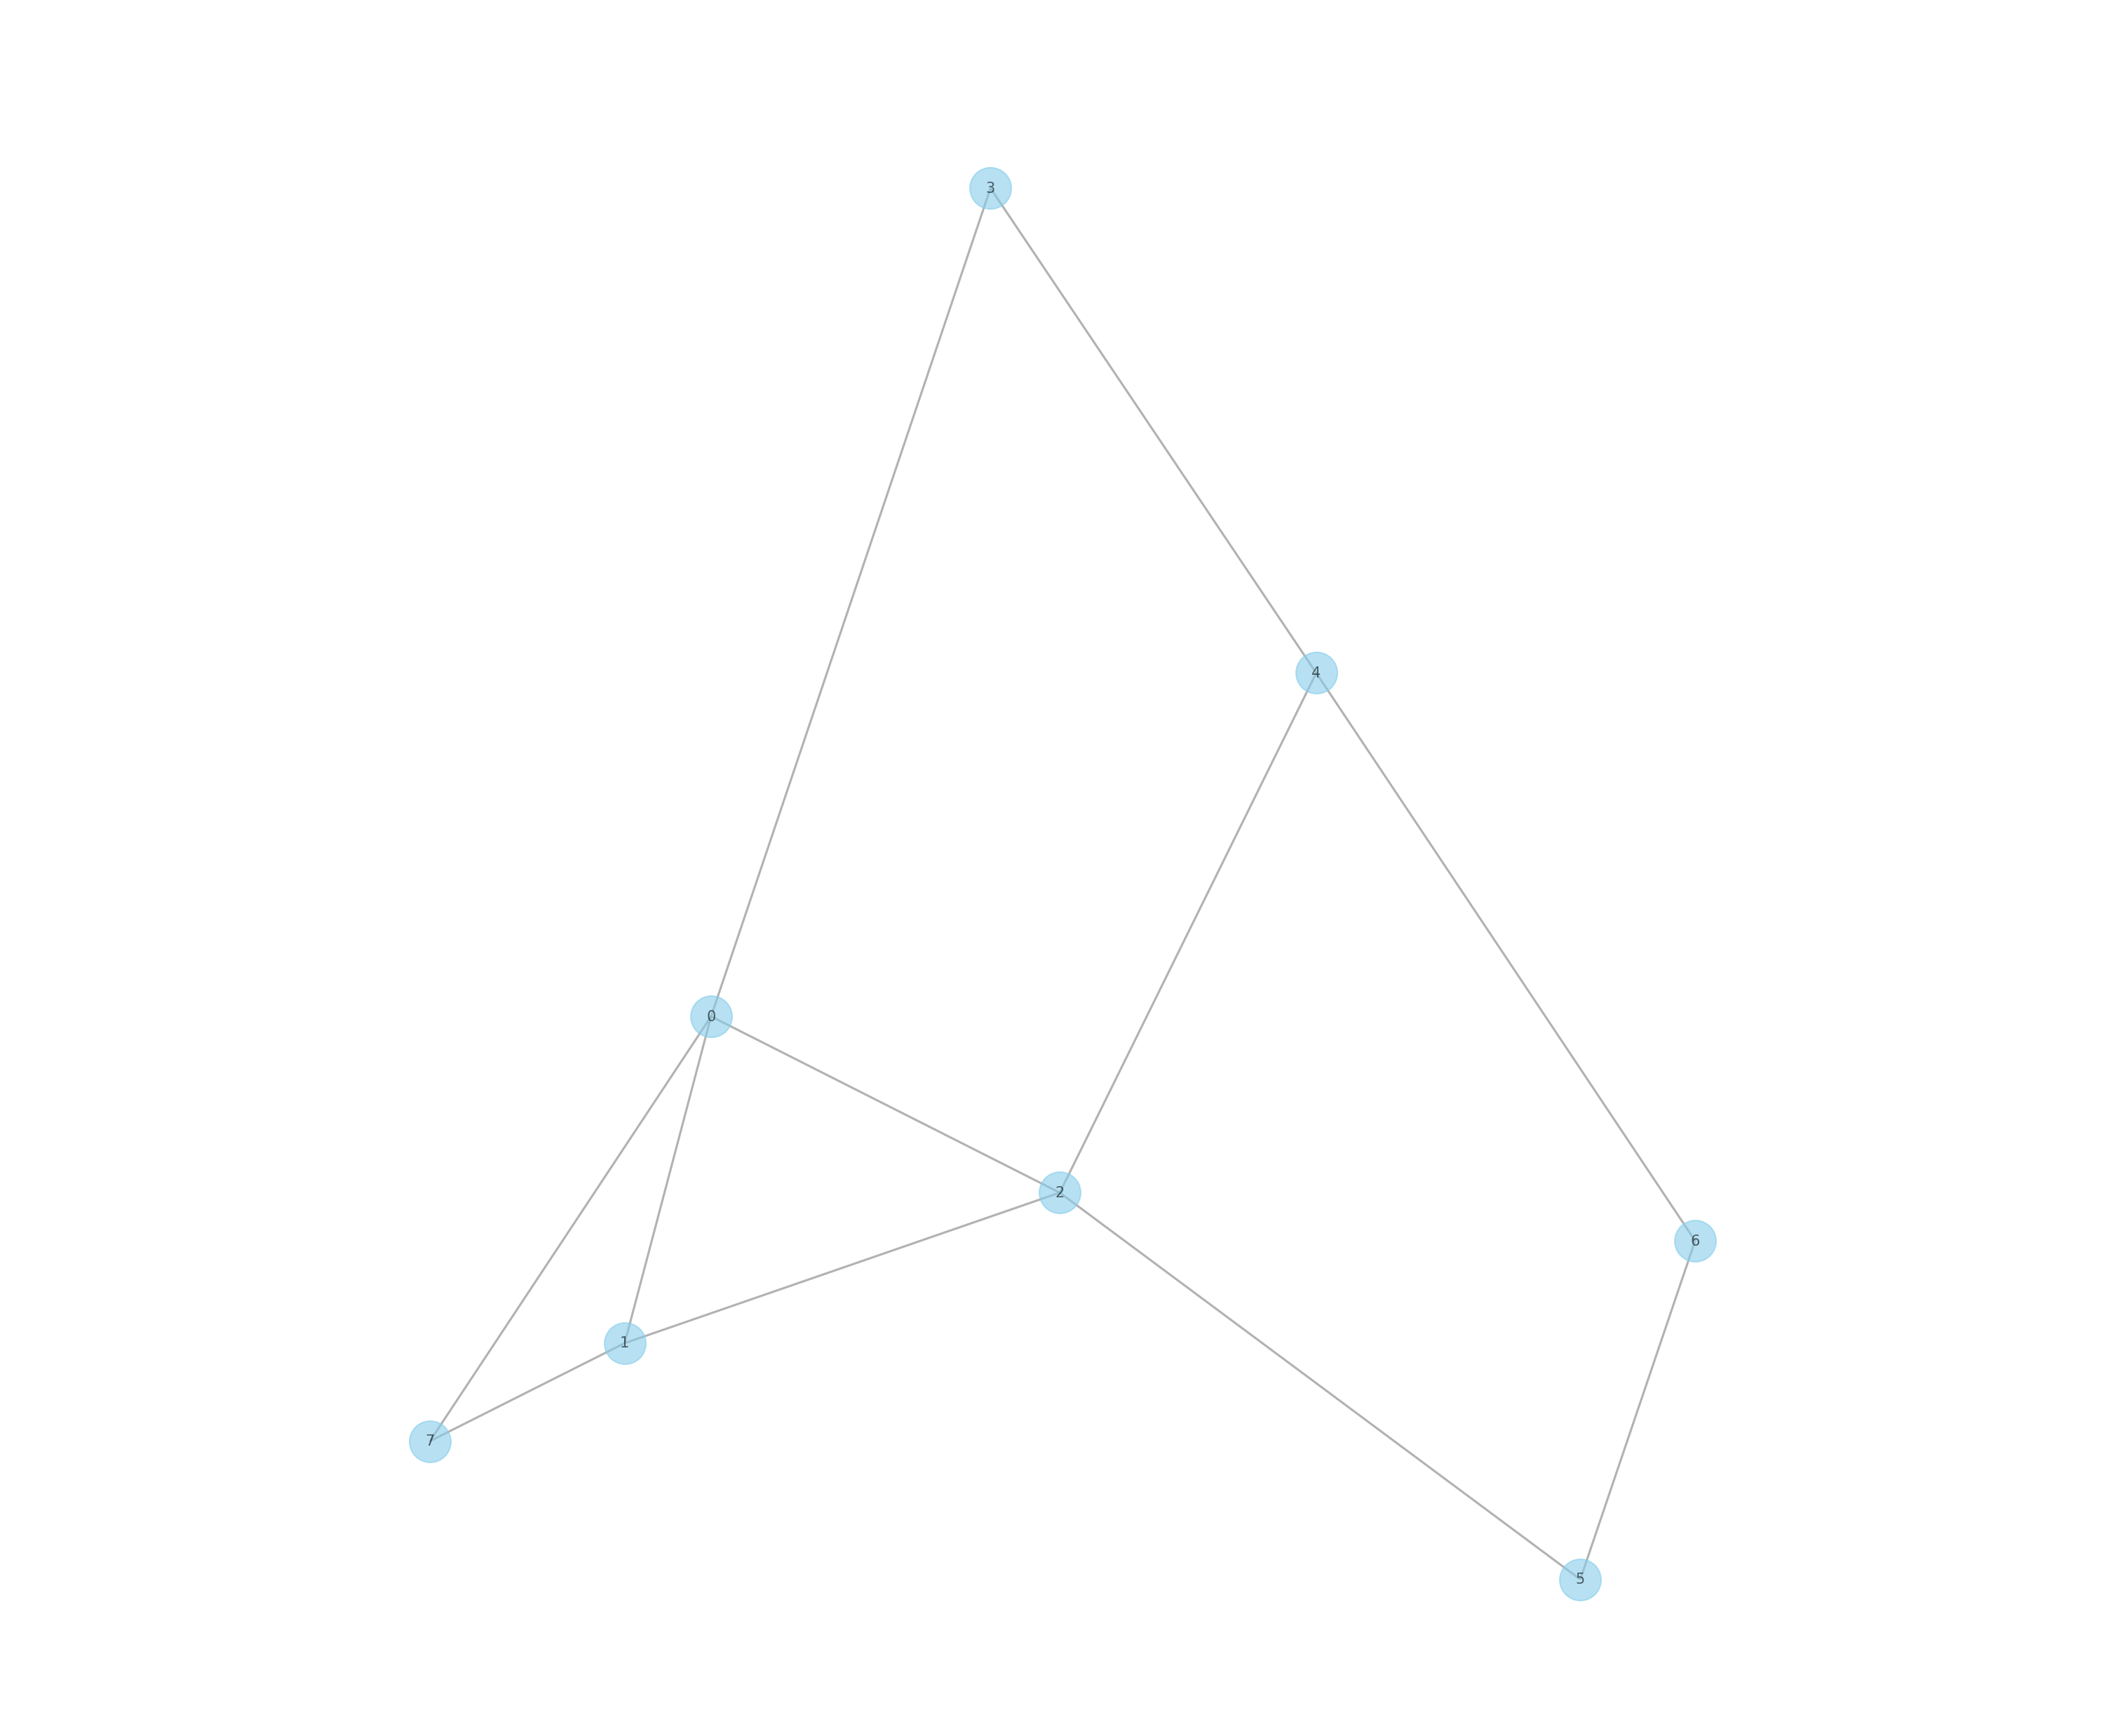

In [38]:
l8plus = generateSparseGraphWithNNodes(8)

l8plus = addEdge(l8plus, 4,6)

l8plus = addEdge(l8plus, 0,7)
l8plus = addEdge(l8plus, 0,2)


drawSpectralGraph(l8plus, " ")

## Griglia da 64 nodi analisi classica


/var/folders/8r/vkn7nxys7qd013m1phzf6nr80000gn/T/ipykernel_25992/1394735895.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


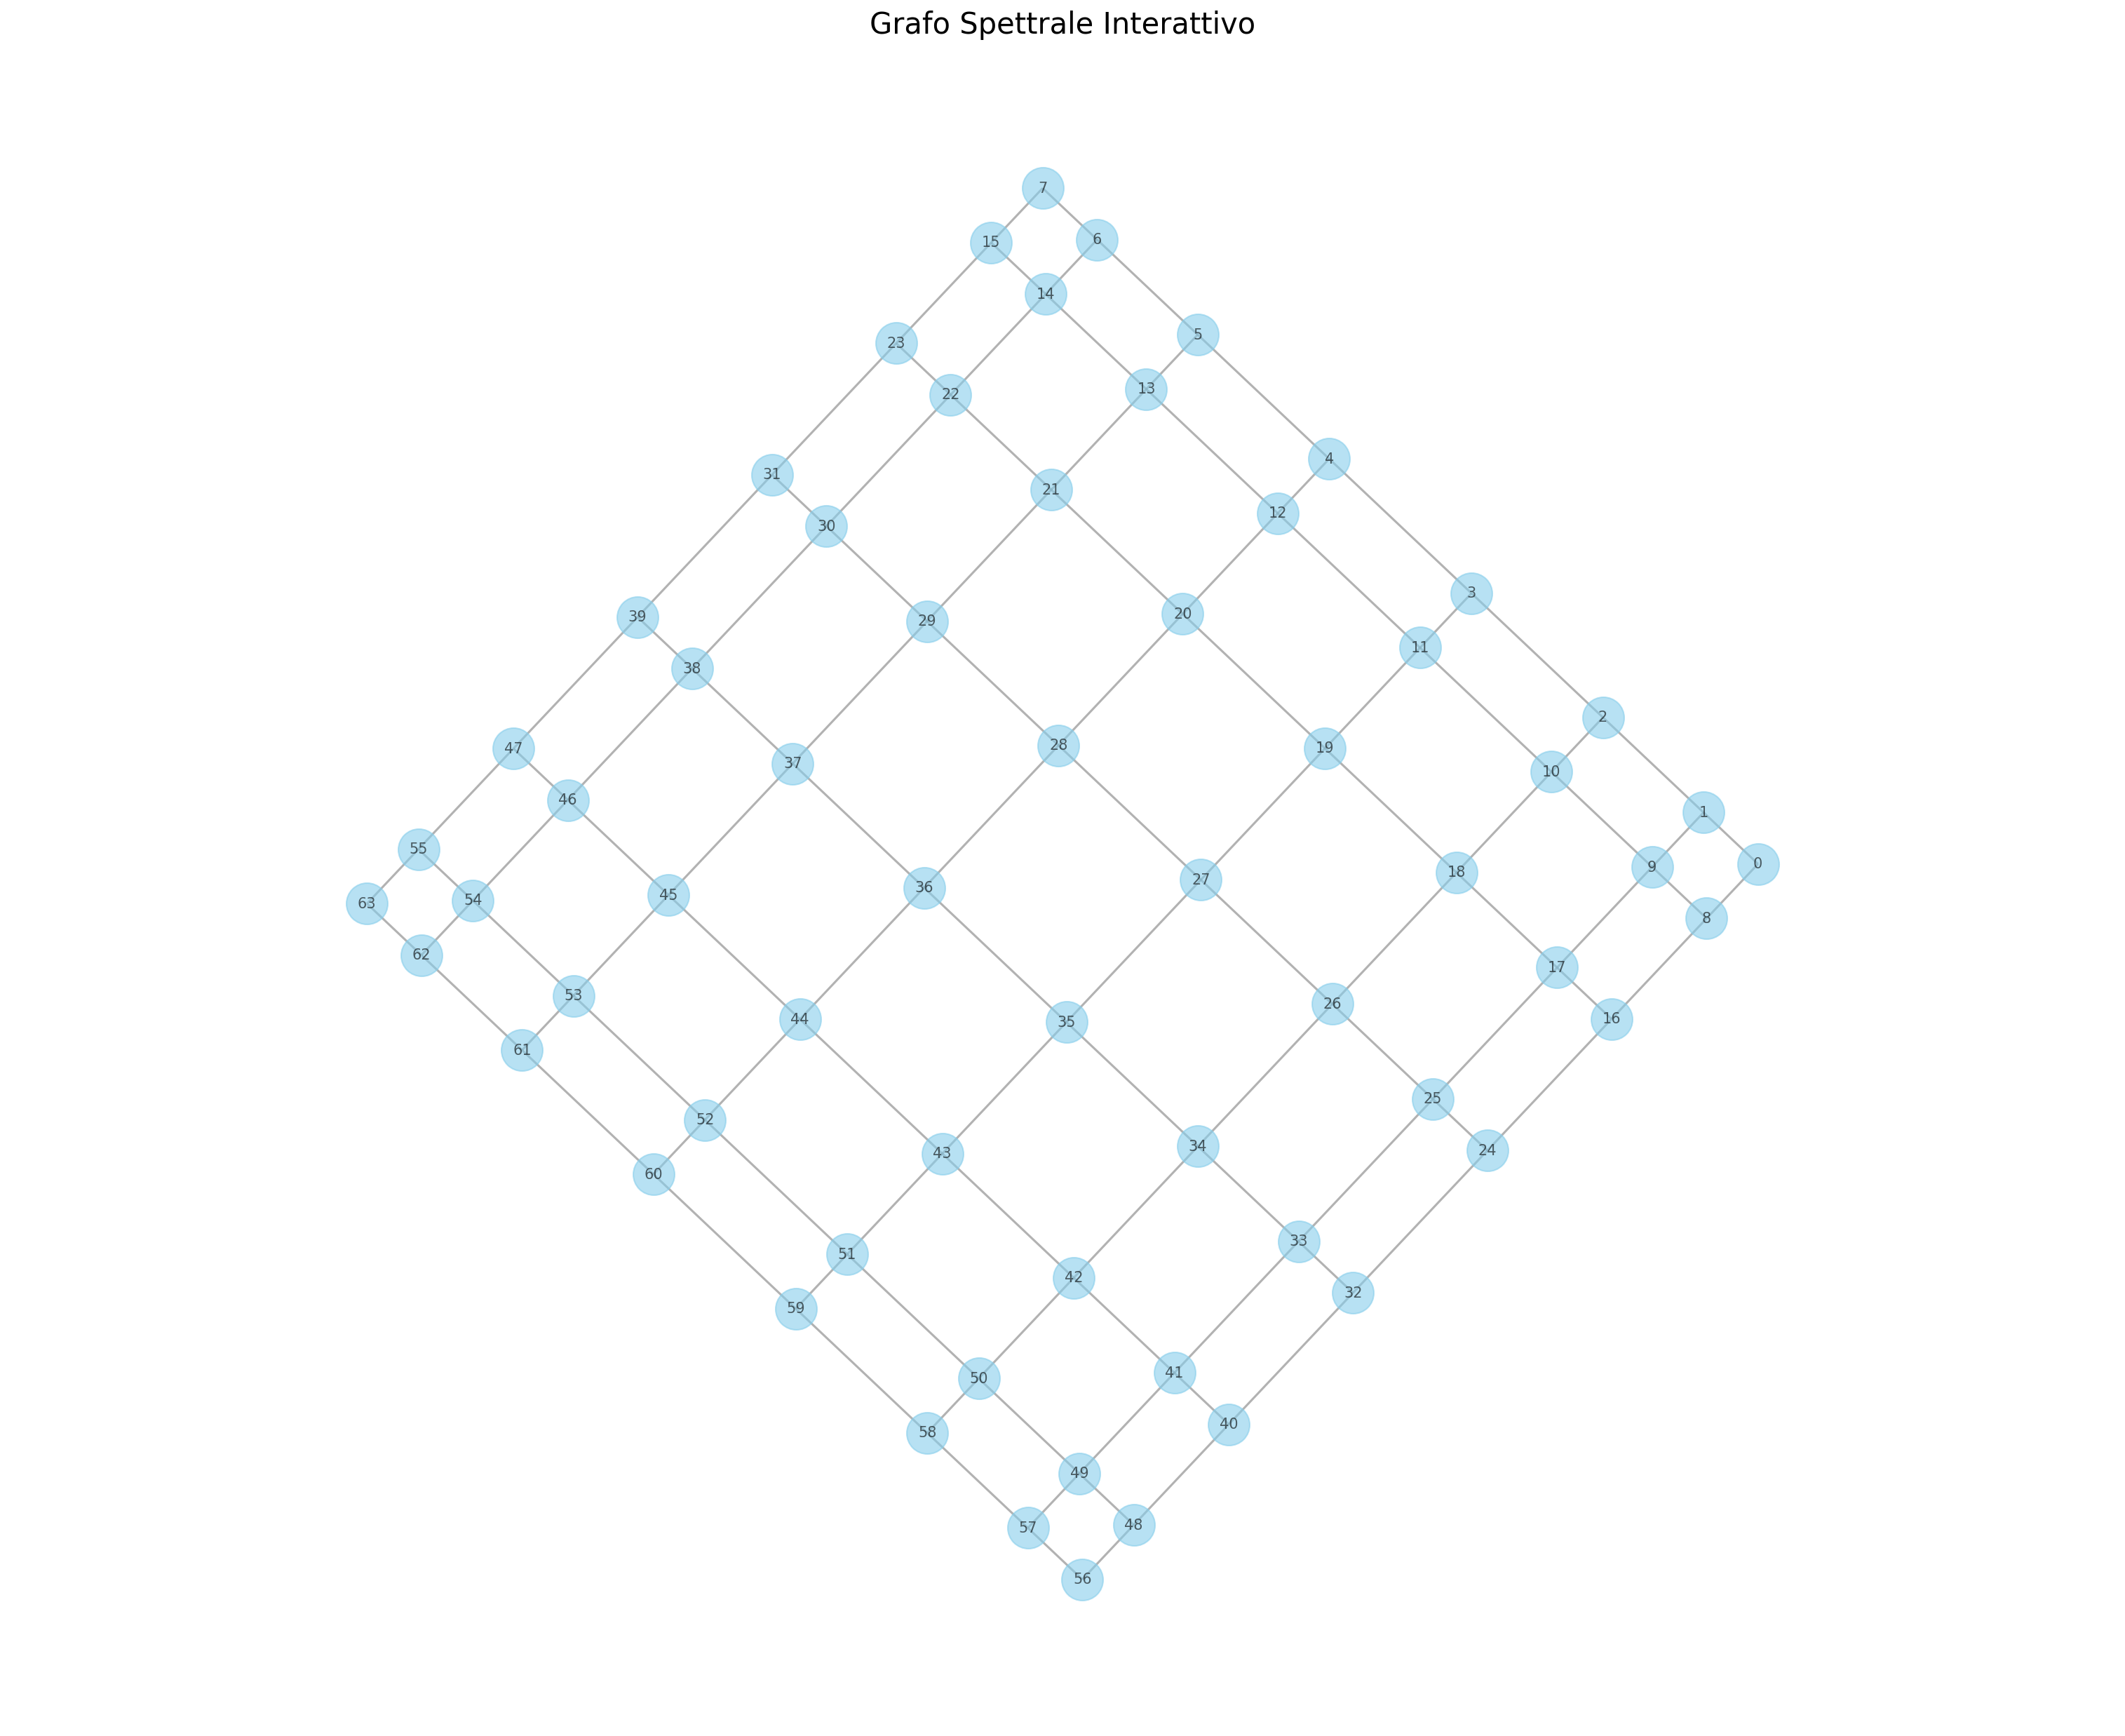

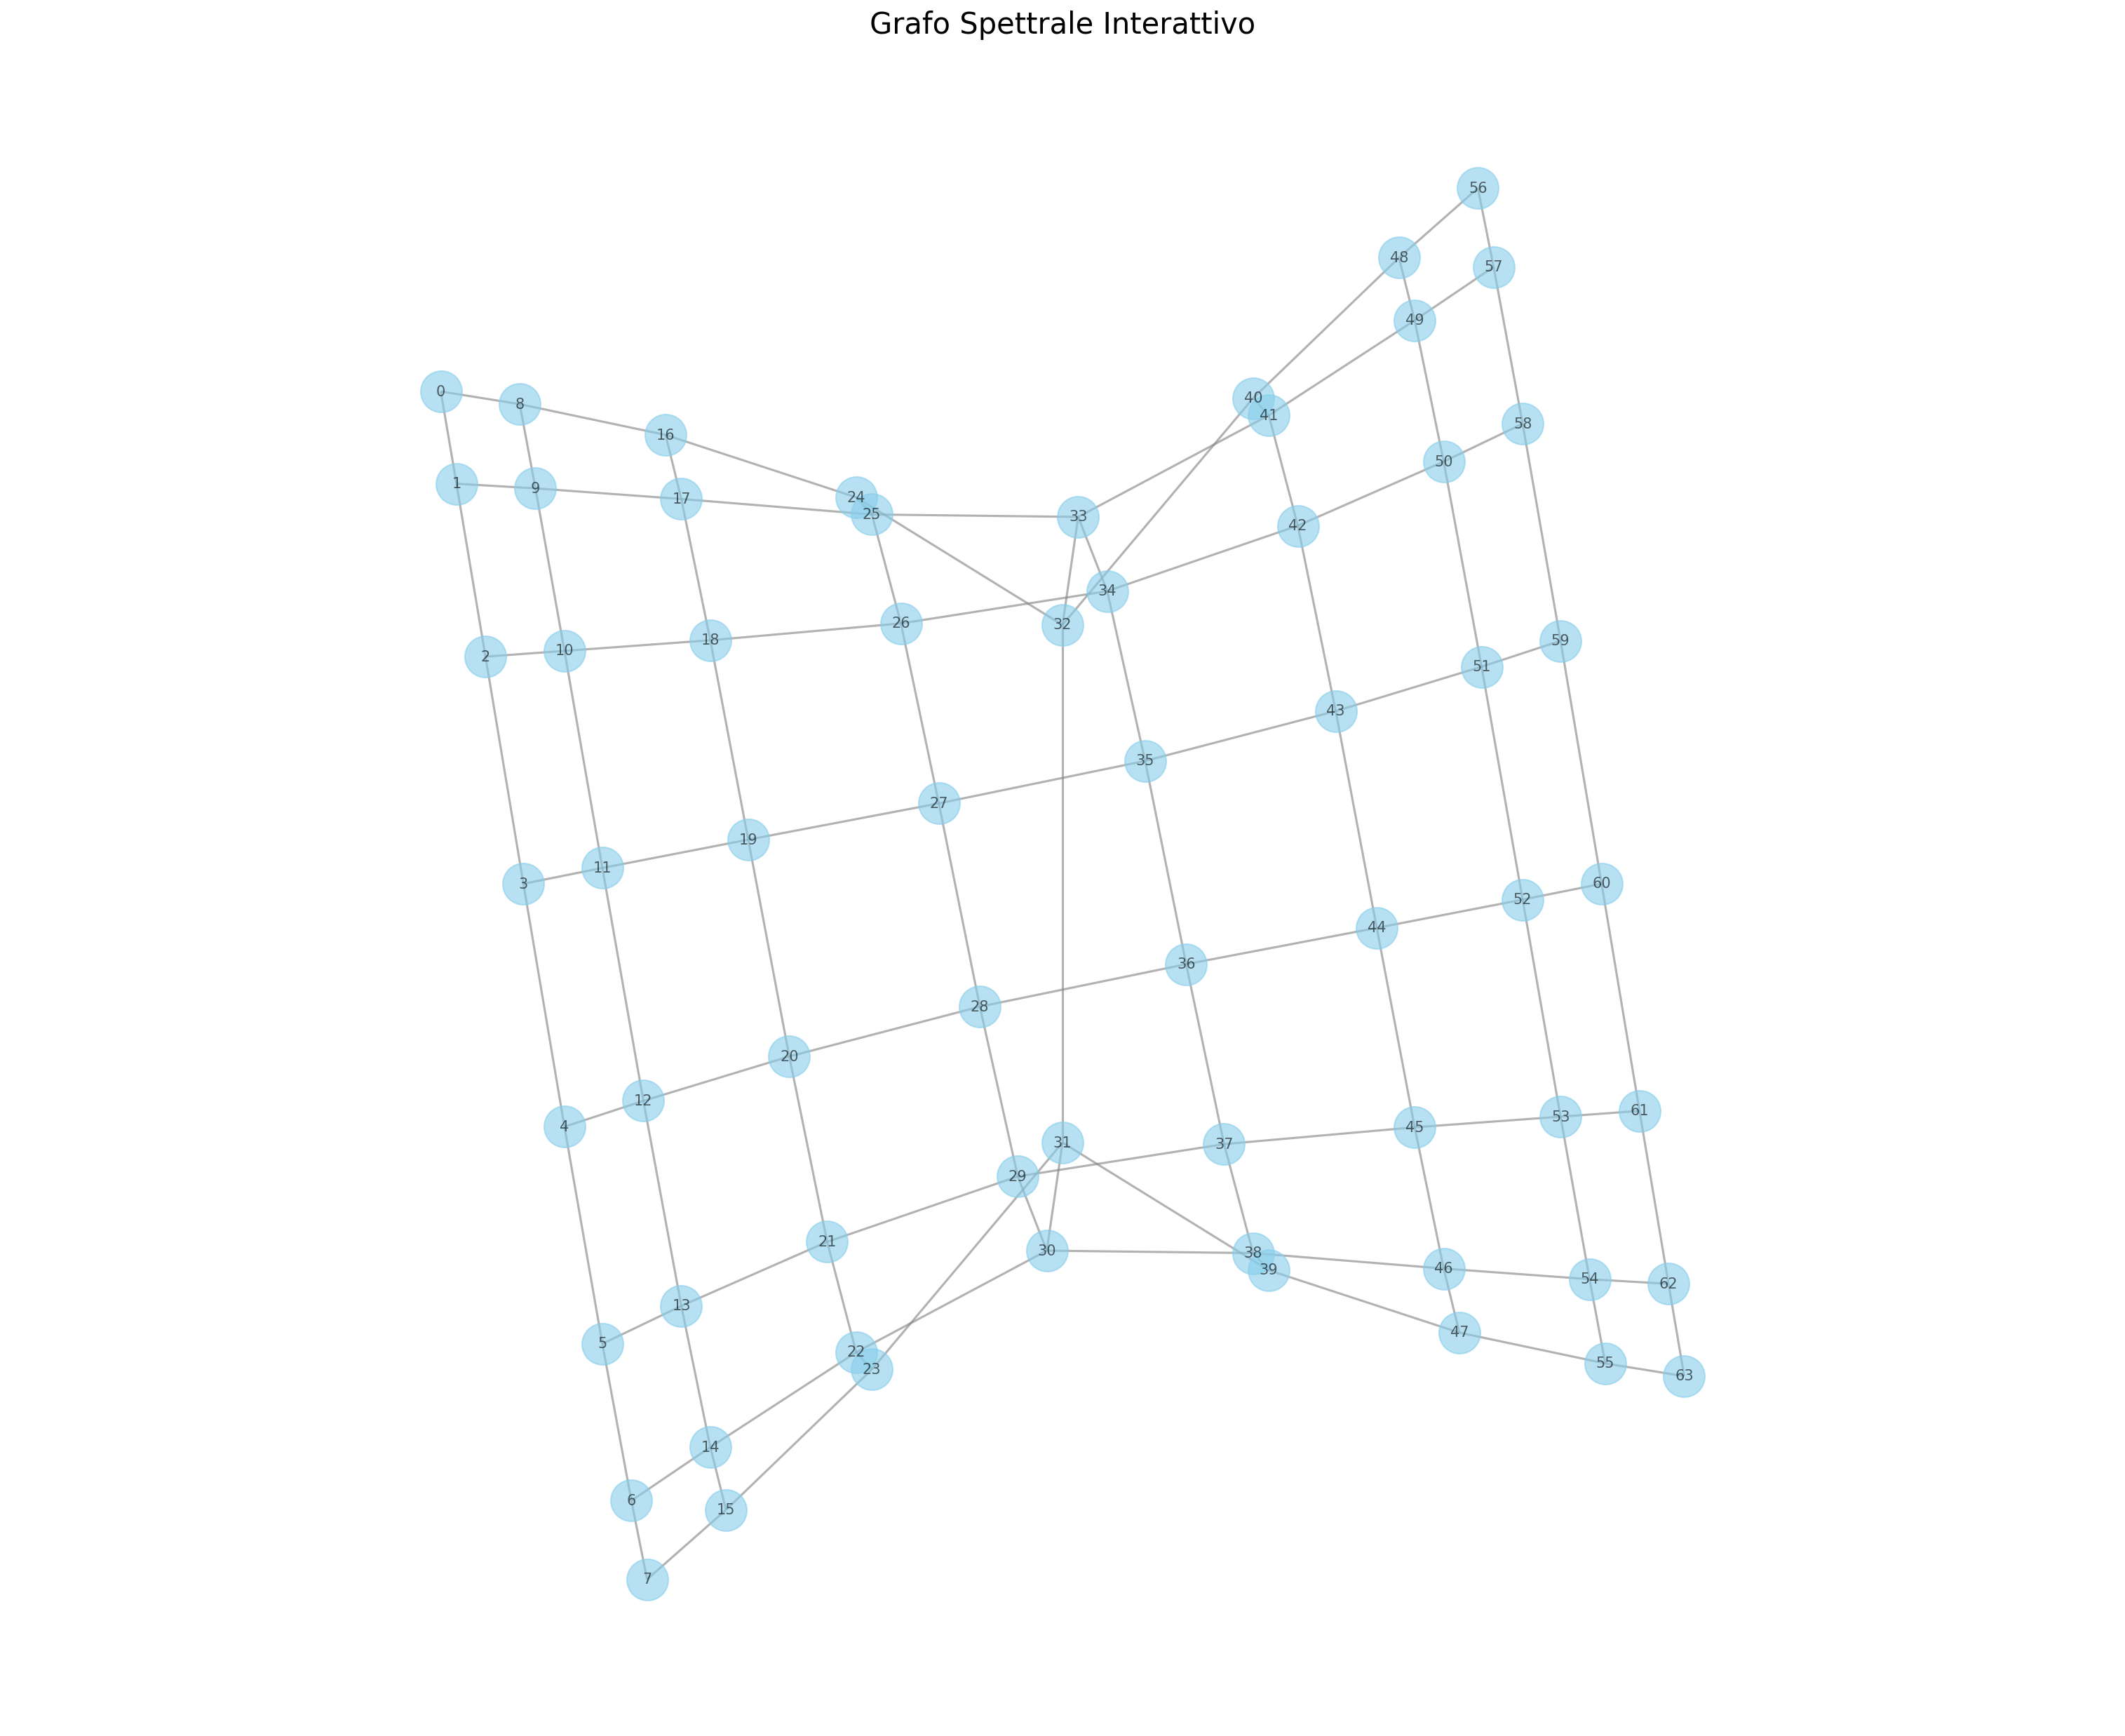

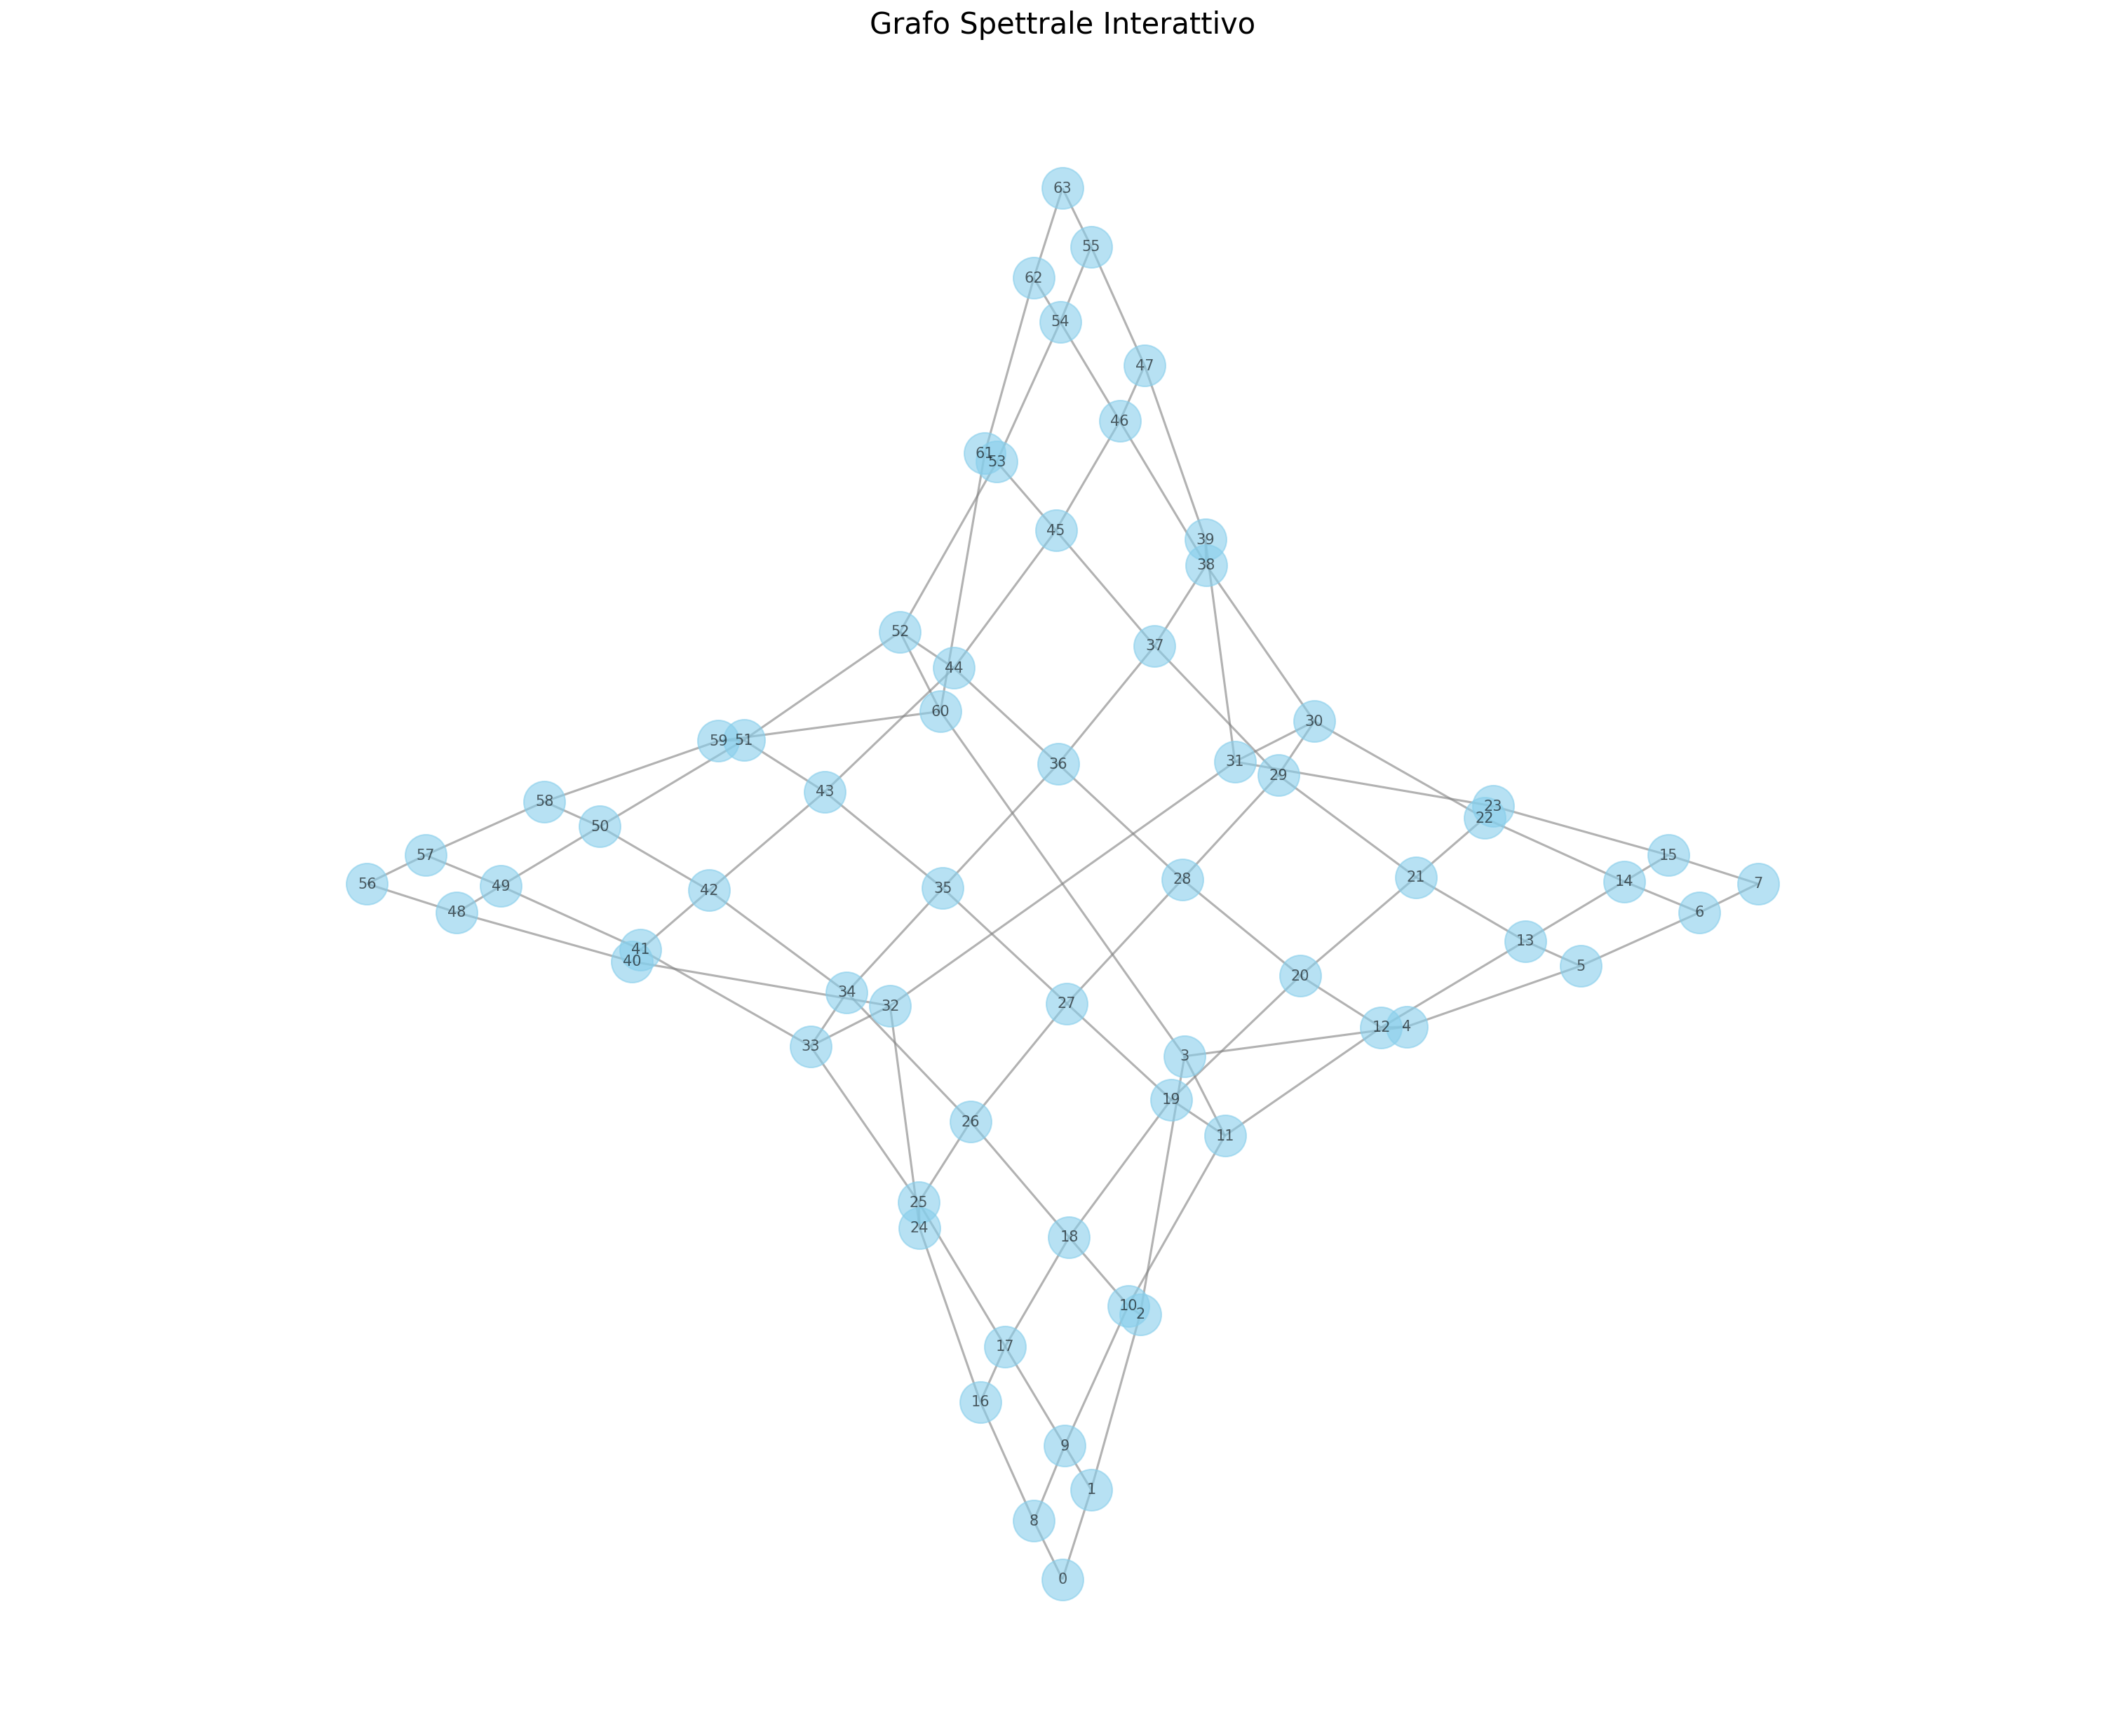

In [ ]:
n_rows = 8
n_cols = 8

G = nx.grid_2d_graph(n_rows, n_cols)
griglia = nx.laplacian_matrix(G).toarray()

drawSpectralGraph(griglia)

griglia = addEdge(griglia, 31, 32)

drawSpectralGraph(griglia)

griglia = addEdge(griglia, 3, 60)


drawSpectralGraph(griglia)

In [ ]:
classical_lambda2_check(griglia, targetThreshold=0.155, numberOfEdgesToRemove=1)


Verifica classica (lambda_2 dopo rimozione di 1 arco/i, 114 combinazioni):
  indici [0] = (0,1): lambda_2 = 0.2069
  indici [1] = (0,8): lambda_2 = 0.2101
  indici [2] = (1,2): lambda_2 = 0.1946
  indici [3] = (1,9): lambda_2 = 0.2121
  indici [4] = (2,3): lambda_2 = 0.1823
  indici [5] = (2,10): lambda_2 = 0.2131
  indici [6] = (3,4): lambda_2 = 0.1898
  indici [7] = (3,11): lambda_2 = 0.2105
  indici [8] = (3,60): lambda_2 = 0.1522  <-- sotto soglia
  indici [9] = (4,5): lambda_2 = 0.1948
  indici [10] = (4,12): lambda_2 = 0.2130
  indici [11] = (5,6): lambda_2 = 0.2026
  indici [12] = (5,13): lambda_2 = 0.2117
  indici [13] = (6,7): lambda_2 = 0.2101
  indici [14] = (6,14): lambda_2 = 0.2104
  indici [15] = (7,15): lambda_2 = 0.2069
  indici [16] = (8,9): lambda_2 = 0.2104
  indici [17] = (8,16): lambda_2 = 0.2026
  indici [18] = (9,10): lambda_2 = 0.2040
  indici [19] = (9,17): lambda_2 = 0.2079
  indici [20] = (10,11): lambda_2 = 0.1990
  indici [21] = (10,18): lambda_2 = 0.2102
